In [401]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer , PageBreak
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from datetime import datetime

In [402]:
api_request_data = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_api_requests.xlsx")

api_request_data.head()

,api_request_id,service_name,endpoint,method,status_code,response_ms,request_time,merchant_id,client_ip,error_details
0,1,web-gateway,/v1/cart/checkout,GET,200,269,2025-10-03 05:35:45,10.0,46.171.199.240,NaN
1,2,web-gateway,/v1/cart/calculate-shipping,POST,200,187,2025-09-01 10:32:05,78.0,229.112.210.41,NaN
2,3,inventory-processor,/v1/health,POST,200,201,2025-08-24 21:48:49,NaN,151.41.126.100,NaN
3,4,inventory-processor,/v1/cart/calculate-shipping,POST,200,247,2025-10-08 20:40:27,92.0,156.210.35.242,NaN
4,5,checkout-service,/v1/catalog,GET,200,284,2025-08-28 20:47:05,11.0,22.132.57.32,NaN


In [403]:
api_request_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   api_request_id  50000 non-null  int64         
 1   service_name    50000 non-null  object        
 2   endpoint        50000 non-null  object        
 3   method          50000 non-null  object        
 4   status_code     50000 non-null  int64         
 5   response_ms     50000 non-null  int64         
 6   request_time    50000 non-null  datetime64[ns]
 7   merchant_id     34729 non-null  float64       
 8   client_ip       50000 non-null  object        
 9   error_details   344 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 3.8+ MB


In [404]:
api_request_data['time'] = api_request_data['request_time'].dt.time

In [405]:
api_request_data.isnull().sum()

api_request_id        0
service_name          0
endpoint              0
method                0
status_code           0
response_ms           0
request_time          0
merchant_id       15271
client_ip             0
error_details     49656
time                  0
dtype: int64

In [406]:
api_request_data.duplicated().sum()

np.int64(0)

In [407]:
conditions = [
    api_request_data['status_code'] == 200,
    api_request_data['status_code'].isin([400, 404]),
    api_request_data['status_code'].isin([500, 503, 504])
]

choices = ['Success', 'Bad Request', 'Internal Server Error']

api_request_data['HTTP_Response_code'] = np.select(conditions, choices, default='Other')


In [408]:
api_request_data.describe()

,api_request_id,status_code,response_ms,request_time,merchant_id
count,50000.000000,50000.000000,50000.00000,50000,34729.000000
mean,25000.500000,206.268040,195.86618,2025-08-27 18:44:51.938133760,50.718535
min,1.000000,200.000000,50.00000,2025-07-13 00:17:12,1.000000
25%,12500.750000,200.000000,114.00000,2025-08-05 05:24:02.249999872,26.000000
50%,25000.500000,200.000000,177.00000,2025-08-27 19:18:10,51.000000
75%,37500.250000,200.000000,239.00000,2025-09-19 06:30:01.249999872,76.000000
max,50000.000000,504.000000,4498.00000,2025-10-11 15:48:47,100.000000
std,14433.901067,37.887295,257.71092,NaN,28.768573


<Axes: >

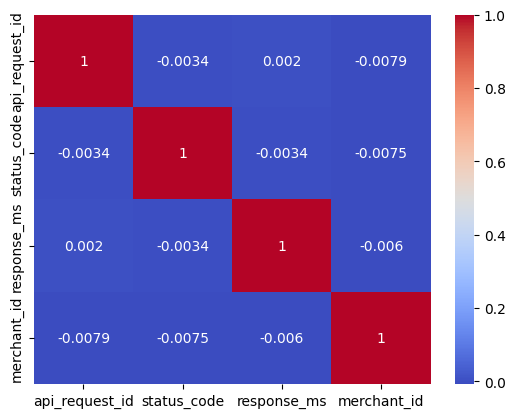

In [409]:
data_corr = api_request_data.corr( numeric_only=True)

sns.heatmap(data_corr, annot=True, cmap='coolwarm')

In [410]:
count_sucess_request = api_request_data[api_request_data['HTTP_Response_code'] == 'Success'].shape[0]
count_error_request = api_request_data[api_request_data['HTTP_Response_code'] != 'Success'].shape[0]
total_request = count_sucess_request + count_error_request
failure_rate = (count_error_request / total_request) * 100
uptime = (count_sucess_request / total_request) * 100
avg_response_time = api_request_data['response_ms'].mean()
p95_latency = api_request_data['response_ms'].quantile(0.95)
p99_latency = api_request_data['response_ms'].quantile(0.99)

print(f"Number of successful requests: {count_sucess_request}")
print(f"Number of error requests: {count_error_request}")
print(f"Total number of requests: {total_request}")
print(f"Failure rate: {failure_rate:.2f}%")
print(f"Uptime: {uptime:.2f}%")
print(f"Average response time: {avg_response_time} ms")
print(f"95th percentile latency: {p95_latency} ms")
print(f"99th percentile latency: {p99_latency} ms")

Number of successful requests: 48619
Number of error requests: 1381
Total number of requests: 50000
Failure rate: 2.76%
Uptime: 97.24%
Average response time: 195.86618 ms
95th percentile latency: 290.0 ms
99th percentile latency: 300.0 ms


In [411]:
method_response_mean = api_request_data.groupby('method')['response_ms'].mean().sort_values(ascending=False)

print(f"http_method_response_mean: {method_response_mean} ms")

http_method_response_mean: method
POST    197.085307
GET     194.638637
Name: response_ms, dtype: float64 ms


In [412]:
http_method_response_mean = api_request_data.groupby('HTTP_Response_code')['response_ms'].mean().sort_values(ascending=False)

print(f"http_method_response_mean: {http_method_response_mean} ms")

http_method_response_mean: HTTP_Response_code
Internal Server Error    218.284884
Success                  196.116066
Bad Request              176.713597
Name: response_ms, dtype: float64 ms


In [413]:
request_volume_endpoint = api_request_data['endpoint'].value_counts()
request_volume_endpoint

endpoint
/v1/cart/checkout              7375
/v1/process_payment            7153
/v2/update_inventory           7148
/v1/cart/calculate-shipping    7100
/v1/health                     7085
/v1/catalog                    7077
/v1/create_order               7062
Name: count, dtype: int64

In [414]:
api_request_data.groupby('endpoint')['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

,mean
endpoint,
/v1/create_order,320.002124
/v2/update_inventory,176.489368
/v1/cart/calculate-shipping,175.852113
/v1/health,175.335356
/v1/process_payment,175.319307
/v1/catalog,175.179172
/v1/cart/checkout,174.549831


In [415]:
api_request_data.groupby('client_ip')['response_ms'].agg(['count','mean']).sort_values(by='mean', ascending=False)

,count,mean
client_ip,,
45.64.227.241,1,4498.0
211.208.89.131,1,4495.0
179.102.102.55,1,4488.0
82.192.152.175,1,4482.0
157.98.179.46,1,4472.0
...,...,...
99.157.229.57,1,50.0
236.166.21.157,1,50.0
99.225.92.152,1,50.0


In [416]:
api_request_data.groupby(['endpoint','HTTP_Response_code'])['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

mean
endpoint                    HTTP_Response_code               
/v1/create_order            Success                323.628609
                            Internal Server Error  287.676923
/v1/process_payment         Internal Server Error  182.757576
/v2/update_inventory        Internal Server Error  182.358974
/v1/health                  Bad Request            181.869565
/v1/catalog                 Internal Server Error  179.131579
                            Bad Request            178.602837
/v1/create_order            Bad Request            178.236111
/v1/cart/calculate-shipping Internal Server Error  177.307692
/v1/cart/checkout           Bad Request            176.641176
/v2/update_inventory        Success                176.564077
/v1/process_payment         Bad Request            175.949367
/v1/cart/calculate-shipping Success                175.885875
/v1/process_payment         Success                175.269750
/v1/health                  Success                175.237563
/v1/catalog                 Success                175.087417
/v1/cart/checkout           Success                174.523086
/v1/cart/calculate-shipping Bad Request            173.615385
/v2/update_inventory        Bad Request            170.849624
/v1/cart/checkout           Internal Server Error  170.000000
/v1/health                  Internal Server Error  162.310345

In [417]:
api_request_data.groupby(['status_code','method'])['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

mean
status_code method            
503         POST    334.500000
            GET     328.770833
200         POST    197.398761
            GET     194.826121
504         GET     181.507246
500         GET     180.812500
404         POST    178.940711
500         POST    176.507246
404         GET     176.209877
400         GET     176.015094
            POST    175.786232
504         POST    174.676471

In [418]:
api_request_data.groupby(['endpoint', 'method'])['response_ms'].agg(
    mean='mean',
    p95_latency=lambda x: x.quantile(0.95)
).sort_values(by='mean', ascending=False)


mean  p95_latency
endpoint                    method                         
/v1/create_order            POST    324.052443       1612.2
                            GET     315.735097        458.8
/v2/update_inventory        POST    177.375987        288.0
/v1/cart/calculate-shipping GET     176.041477        287.0
/v1/process_payment         GET     175.902554        288.0
/v1/cart/calculate-shipping POST    175.665922        287.0
/v1/catalog                 POST    175.625036        288.0
/v2/update_inventory        GET     175.552230        289.0
/v1/health                  GET     175.451829        288.0
/v1/cart/checkout           POST    175.255707        288.0
/v1/health                  POST    175.216324        288.0
/v1/catalog                 GET     174.749028        287.0
/v1/process_payment         POST    174.727682        288.0
/v1/cart/checkout           GET     173.846820        287.0

In [419]:
api_request_data.groupby('service_name')['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

,mean
service_name,
orders-api,198.510743
web-gateway,196.980902
checkout-service,196.454664
reporting-etl,195.806139
inventory-processor,191.666798


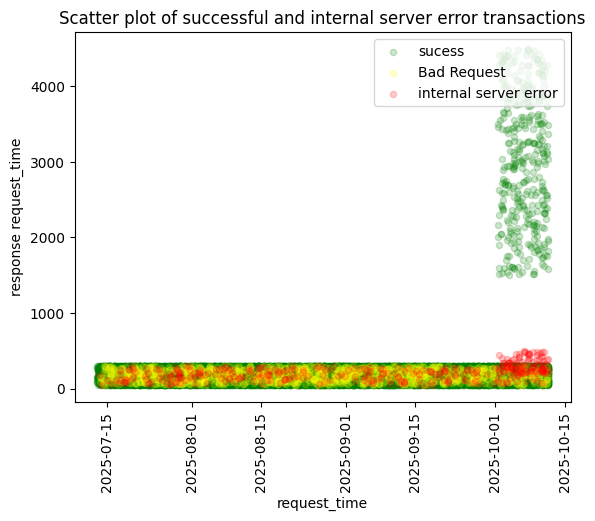

In [420]:
# plotting success vs internal server error vs Bad Request

alpha = 0.2
fig,ax = plt.subplots()
api_request_data[api_request_data["status_code"] == 200].plot.scatter(x="request_time",y="response_ms",color="green",alpha=alpha,ax=ax,label="sucess")
api_request_data[api_request_data["status_code"].isin([400, 404])].plot.scatter(x="request_time",y="response_ms",color="yellow",alpha=alpha,ax=ax, label="Bad Request")
api_request_data[api_request_data["status_code"].isin([500, 503, 504])].plot.scatter(x="request_time",y="response_ms",color="red",alpha=alpha,ax=ax, label="internal server error")

plt.title("Scatter plot of successful and internal server error transactions")
plt.xlabel("request_time")
plt.ylabel("response request_time")
plt.xticks(rotation=90)
plt.legend(loc="upper right")

plt.show()

In [421]:
# Calculate percentages of success and internal server error for response times less than 300, 350, 500 ms before 2025-10-01
thresholds = [300, 350, 500]
percentages = {}

for threshold in thresholds:
    filtered_data = api_request_data[(api_request_data['response_ms'] < threshold) & (api_request_data['request_time'].dt.date < pd.to_datetime('2025-10-01').date())]
    total_filtered = filtered_data.shape[0]
    if total_filtered > 0:
        success_count = filtered_data[filtered_data['status_code'] == 200].shape[0]
        Bad_request_count = filtered_data[filtered_data['status_code'].isin([400, 404])].shape[0]
        internal_server_error_count = filtered_data[filtered_data['status_code'].isin([500, 503, 504])].shape[0]
        percentages[threshold] = {
            'success_percent': (success_count / total_filtered) * 100,
            'internal_server_error_percent': (internal_server_error_count / total_filtered) * 100,
            'Bad_request_percent': (Bad_request_count / total_filtered) * 100
        }
    else:
        percentages[threshold] = {
            'success_percent': 0,
            'internal_server_error_percent': 0,
            'Bad_request_percent': 0
        }

for threshold, values in percentages.items():
    print(f"For response times less than {threshold} ms:")
    print(f"  Success percentage: {values['success_percent']:.2f}%")
    print(f"  Internal Server Error percentage: {values['internal_server_error_percent']:.2f}%")
    print(f"  Bad Request percentage: {values['Bad_request_percent']:.2f}%")
    print()

For response times less than 300 ms:
  Success percentage: 97.37%
  Internal Server Error percentage: 0.51%
  Bad Request percentage: 2.12%

For response times less than 350 ms:
  Success percentage: 97.37%
  Internal Server Error percentage: 0.51%
  Bad Request percentage: 2.12%

For response times less than 500 ms:
  Success percentage: 97.37%
  Internal Server Error percentage: 0.51%
  Bad Request percentage: 2.12%



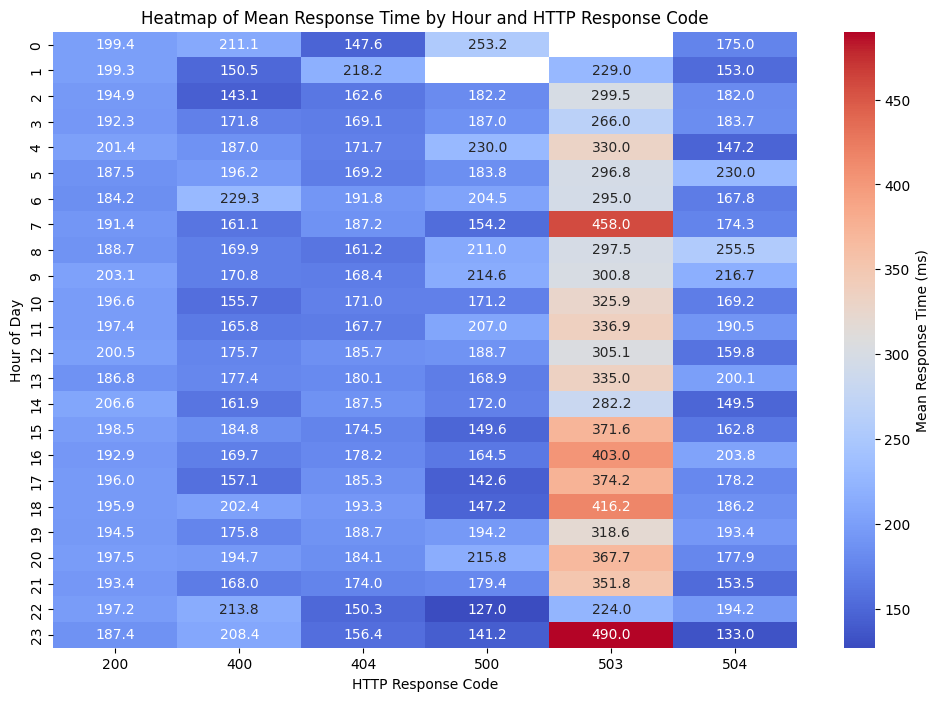

In [422]:
# Heatmap for Success and Internal Server Error
api_request_data['hour'] = api_request_data['request_time'].dt.hour
# Create a pivot table for heatmap
data_pivot = api_request_data.pivot_table(
    index='hour', 
    columns='status_code', 
    values='response_ms', 
    aggfunc='mean'
)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data_pivot, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={'label': 'Mean Response Time (ms)'})
plt.title('Heatmap of Mean Response Time by Hour and HTTP Response Code')
plt.xlabel('HTTP Response Code')
plt.ylabel('Hour of Day')
plt.show()

In [423]:
api_request_data['error_details'].sort_values(ascending=False)

25143    {"error": "Service Unavailable: DB Pool Exhaus...
10132    {"error": "Service Unavailable: DB Pool Exhaus...
18169    {"error": "Service Unavailable: DB Pool Exhaus...
36122    {"error": "Service Unavailable: DB Pool Exhaus...
37011    {"error": "Service Unavailable: DB Pool Exhaus...
                               ...                        
49995                                                  NaN
49996                                                  NaN
49997                                                  NaN
49998                                                  NaN
49999                                                  NaN
Name: error_details, Length: 50000, dtype: object

In [424]:
api_request_data.groupby('error_details')['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

,mean
error_details,
"{""error"": ""Service Unavailable: DB Pool Exhausted"", ""cause"": ""Recent deployment change""}",331.444444
"{""error"": ""Internal Server Error: Unhandled Exception""}",178.188976


In [425]:
service_unavailable = api_request_data[api_request_data['error_details'].str.contains('"error": "Service Unavailable: DB Pool Exhausted", "cause": "Recent deployment change"', na=False)]

service_unavailable.head()

,api_request_id,service_name,endpoint,method,status_code,response_ms,request_time,merchant_id,client_ip,error_details,time,HTTP_Response_code,hour
576,577,orders-api,/v1/create_order,GET,503,292,2025-10-06 10:50:30,33.0,120.103.140.88,"{""error"": ""Service Unavailable: DB Pool Exhaus...",10:50:30,Internal Server Error,10
621,622,orders-api,/v1/create_order,GET,503,288,2025-10-03 11:18:58,NaN,112.190.36.178,"{""error"": ""Service Unavailable: DB Pool Exhaus...",11:18:58,Internal Server Error,11
1993,1994,reporting-etl,/v1/create_order,POST,503,214,2025-10-07 05:07:11,89.0,189.58.83.132,"{""error"": ""Service Unavailable: DB Pool Exhaus...",05:07:11,Internal Server Error,5
3921,3922,checkout-service,/v1/create_order,GET,503,201,2025-10-01 19:01:06,9.0,35.76.48.108,"{""error"": ""Service Unavailable: DB Pool Exhaus...",19:01:06,Internal Server Error,19
4871,4872,orders-api,/v1/create_order,GET,503,482,2025-10-10 20:46:48,NaN,89.164.68.196,"{""error"": ""Service Unavailable: DB Pool Exhaus...",20:46:48,Internal Server Error,20


In [426]:
service_unavailable.groupby(['service_name','HTTP_Response_code'])['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

,,mean
service_name,HTTP_Response_code,
reporting-etl,Internal Server Error,365.400000
web-gateway,Internal Server Error,338.357143
orders-api,Internal Server Error,328.631579
checkout-service,Internal Server Error,322.736842
inventory-processor,Internal Server Error,314.608696


In [427]:
service_unavailable.groupby('client_ip')['response_ms'].agg(['count','mean']).sort_values(by='mean', ascending=False)

,count,mean
client_ip,,
61.182.29.21,1,500.0
70.17.1.241,1,490.0
18.8.141.99,1,488.0
230.253.155.188,1,486.0
243.163.89.245,1,486.0
...,...,...
9.226.148.147,1,208.0
174.180.90.1,1,207.0
196.130.235.239,1,202.0


In [428]:
bad_request = api_request_data[api_request_data['error_details'].str.contains('"error": "Internal Server Error: Unhandled Exception"', na=False)]

bad_request.head()

,api_request_id,service_name,endpoint,method,status_code,response_ms,request_time,merchant_id,client_ip,error_details,time,HTTP_Response_code,hour
211,212,web-gateway,/v1/cart/calculate-shipping,GET,500,56,2025-08-26 12:38:02,NaN,185.225.234.204,"{""error"": ""Internal Server Error: Unhandled Ex...",12:38:02,Internal Server Error,12
405,406,orders-api,/v1/cart/calculate-shipping,GET,504,214,2025-09-18 04:34:35,92.0,47.22.41.56,"{""error"": ""Internal Server Error: Unhandled Ex...",04:34:35,Internal Server Error,4
559,560,orders-api,/v1/create_order,GET,504,106,2025-09-18 07:06:28,59.0,77.73.75.143,"{""error"": ""Internal Server Error: Unhandled Ex...",07:06:28,Internal Server Error,7
767,768,orders-api,/v1/create_order,GET,500,247,2025-08-08 12:59:09,57.0,3.136.221.188,"{""error"": ""Internal Server Error: Unhandled Ex...",12:59:09,Internal Server Error,12
770,771,orders-api,/v1/cart/calculate-shipping,GET,504,206,2025-08-01 13:35:32,NaN,251.191.28.224,"{""error"": ""Internal Server Error: Unhandled Ex...",13:35:32,Internal Server Error,13


In [429]:
bad_request.groupby(['service_name','HTTP_Response_code'])['response_ms'].agg(['mean']).sort_values(by='mean', ascending=False)

,,mean
service_name,HTTP_Response_code,
inventory-processor,Internal Server Error,181.980392
orders-api,Internal Server Error,178.950820
web-gateway,Internal Server Error,177.540541
checkout-service,Internal Server Error,176.358491
reporting-etl,Internal Server Error,175.903846


In [430]:
bad_request.groupby('client_ip')['response_ms'].agg(['count','mean']).sort_values(by='mean', ascending=False)

,count,mean
client_ip,,
178.59.248.155,1,299.0
165.253.34.126,1,299.0
131.16.14.181,1,296.0
43.126.100.89,1,296.0
47.203.2.143,1,295.0
...,...,...
148.95.152.222,1,56.0
74.91.199.124,1,53.0
114.34.227.47,1,53.0


In [431]:
incidents_data = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_incidents.xlsx")

incidents_data.head()

,incident_id,title,service_name,severity,created_at,acknowledged_at,resolved_at,status,root_cause,detected_by
0,1,P3 failure in orders-api,orders-api,P3,2025-08-16 07:04:36,2025-08-16 07:13:08,2025-08-16 07:20:49,resolved,Deployment failure,Internal QA
1,2,P1 failure in inventory-processor,inventory-processor,P1,2025-09-12 20:20:41,2025-09-12 12:52:07,2025-09-12 13:35:09,resolved,Bad configuration,Monitoring System
2,3,P3 failure in inventory-processor,inventory-processor,P3,2025-09-10 19:15:25,2025-09-10 11:24:12,2025-09-10 11:40:22,resolved,3rd party API outage,Monitoring System
3,4,P1 failure in inventory-processor,inventory-processor,P1,2025-08-27 10:21:57,2025-08-27 09:30:50,NaT,open,Database connection issue,Customer Report
4,5,P2 failure in checkout-service,checkout-service,P2,2025-07-17 17:23:13,2025-07-17 14:01:05,2025-07-17 13:47:16,resolved,Database connection issue,Proactive Audit


In [432]:
incidents_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   incident_id      100 non-null    int64         
 1   title            100 non-null    object        
 2   service_name     100 non-null    object        
 3   severity         100 non-null    object        
 4   created_at       100 non-null    datetime64[ns]
 5   acknowledged_at  100 non-null    datetime64[ns]
 6   resolved_at      90 non-null     datetime64[ns]
 7   status           100 non-null    object        
 8   root_cause       100 non-null    object        
 9   detected_by      100 non-null    object        
dtypes: datetime64[ns](3), int64(1), object(6)
memory usage: 7.9+ KB


In [433]:
# Ensure datetime conversion for relevant columns
incidents_data['acknowledged_at'] = pd.to_datetime(incidents_data['acknowledged_at'], errors='coerce')
incidents_data['created_at'] = pd.to_datetime(incidents_data['created_at'], errors='coerce')
incidents_data['resolved_at'] = pd.to_datetime(incidents_data['resolved_at'], errors='coerce')


bad_records = incidents_data[
    (incidents_data['acknowledged_at'] < incidents_data['created_at']) |
    (incidents_data['resolved_at'] < incidents_data['acknowledged_at']) |
    (incidents_data['resolved_at'] < incidents_data['created_at']) |
    (incidents_data['resolved_at'].isnull())
]

bad_records.head()


,incident_id,title,service_name,severity,created_at,acknowledged_at,resolved_at,status,root_cause,detected_by
1,2,P1 failure in inventory-processor,inventory-processor,P1,2025-09-12 20:20:41,2025-09-12 12:52:07,2025-09-12 13:35:09,resolved,Bad configuration,Monitoring System
2,3,P3 failure in inventory-processor,inventory-processor,P3,2025-09-10 19:15:25,2025-09-10 11:24:12,2025-09-10 11:40:22,resolved,3rd party API outage,Monitoring System
3,4,P1 failure in inventory-processor,inventory-processor,P1,2025-08-27 10:21:57,2025-08-27 09:30:50,NaT,open,Database connection issue,Customer Report
4,5,P2 failure in checkout-service,checkout-service,P2,2025-07-17 17:23:13,2025-07-17 14:01:05,2025-07-17 13:47:16,resolved,Database connection issue,Proactive Audit
5,6,P0 failure in web-gateway,web-gateway,P0,2025-09-02 14:16:44,2025-09-02 10:52:09,2025-09-02 14:49:40,resolved,3rd party API outage,Internal QA


In [434]:
number_of_wrong_incidents = bad_records.shape[0]

print(f"Number of wrong incidents: {number_of_wrong_incidents}")

Number of wrong incidents: 67


In [435]:
# Subtract bad_records from incidents_data to get correct_incidents
correct_incidents = incidents_data[~incidents_data.index.isin(bad_records.index)]
correct_incidents.head()

,incident_id,title,service_name,severity,created_at,acknowledged_at,resolved_at,status,root_cause,detected_by
0,1,P3 failure in orders-api,orders-api,P3,2025-08-16 07:04:36,2025-08-16 07:13:08,2025-08-16 07:20:49,resolved,Deployment failure,Internal QA
7,8,P0 failure in checkout-service,checkout-service,P0,2025-08-07 05:02:39,2025-08-07 05:04:48,2025-08-07 05:20:09,resolved,Database connection issue,Proactive Audit
10,11,P2 failure in reporting-etl,reporting-etl,P2,2025-07-23 17:43:42,2025-07-23 17:46:38,2025-07-23 18:43:13,resolved,Bad configuration,Monitoring System
13,14,P3 failure in reporting-etl,reporting-etl,P3,2025-08-22 17:44:09,2025-08-22 17:49:05,2025-08-22 20:28:38,resolved,Database connection issue,Internal QA
15,16,P3 failure in checkout-service,checkout-service,P3,2025-08-13 06:15:51,2025-08-13 06:18:28,2025-08-13 09:56:52,resolved,3rd party API outage,Monitoring System


In [436]:
incidents_data.duplicated().sum()

np.int64(0)

In [437]:
incidents_data.isnull().sum()

incident_id         0
title               0
service_name        0
severity            0
created_at          0
acknowledged_at     0
resolved_at        10
status              0
root_cause          0
detected_by         0
dtype: int64

In [438]:
incidents_data[incidents_data['resolved_at'].isnull()]

,incident_id,title,service_name,severity,created_at,acknowledged_at,resolved_at,status,root_cause,detected_by
3,4,P1 failure in inventory-processor,inventory-processor,P1,2025-08-27 10:21:57,2025-08-27 09:30:50,NaT,open,Database connection issue,Customer Report
6,7,P1 failure in orders-api,orders-api,P1,2025-08-03 22:25:45,2025-08-03 10:44:19,NaT,open,Database connection issue,Monitoring System
8,9,P0 failure in reporting-etl,reporting-etl,P0,2025-07-19 17:57:10,2025-07-19 13:23:48,NaT,open,3rd party API outage,Internal QA
22,23,P0 failure in orders-api,orders-api,P0,2025-07-28 10:20:08,2025-07-28 10:21:23,NaT,open,Bad configuration,Proactive Audit
28,29,P3 failure in reporting-etl,reporting-etl,P3,2025-08-29 11:07:23,2025-08-29 11:26:44,NaT,open,Database connection issue,Proactive Audit
31,32,P1 failure in reporting-etl,reporting-etl,P1,2025-07-23 14:30:59,2025-07-23 14:40:05,NaT,open,3rd party API outage,Customer Report
43,44,P0 failure in web-gateway,web-gateway,P0,2025-10-05 19:44:26,2025-10-05 17:26:12,NaT,open,Database connection issue,Monitoring System
56,57,P0 failure in web-gateway,web-gateway,P0,2025-09-20 09:13:00,2025-09-20 06:38:39,NaT,open,Deployment failure,Monitoring System
72,73,P0 failure in checkout-service,checkout-service,P0,2025-09-16 04:43:27,2025-09-16 05:01:42,NaT,open,Bad configuration,Monitoring System
75,76,P3 failure in inventory-processor,inventory-processor,P3,2025-08-10 03:39:04,2025-08-10 03:45:08,NaT,open,Deployment failure,Internal QA


In [439]:
incidents_data['time_to_acknowledge'] = incidents_data['acknowledged_at'] - incidents_data['created_at']
incidents_data['time_to_resolve'] = incidents_data['resolved_at'] - incidents_data['acknowledged_at']

incidents_data['time_to_acknowledge'] = incidents_data['time_to_acknowledge'].dt.total_seconds()
incidents_data['time_to_resolve'] = incidents_data['time_to_resolve'].dt.total_seconds()

incidents_data.head()

,incident_id,title,service_name,severity,created_at,acknowledged_at,resolved_at,status,root_cause,detected_by,time_to_acknowledge,time_to_resolve
0,1,P3 failure in orders-api,orders-api,P3,2025-08-16 07:04:36,2025-08-16 07:13:08,2025-08-16 07:20:49,resolved,Deployment failure,Internal QA,512.0,461.0
1,2,P1 failure in inventory-processor,inventory-processor,P1,2025-09-12 20:20:41,2025-09-12 12:52:07,2025-09-12 13:35:09,resolved,Bad configuration,Monitoring System,-26914.0,2582.0
2,3,P3 failure in inventory-processor,inventory-processor,P3,2025-09-10 19:15:25,2025-09-10 11:24:12,2025-09-10 11:40:22,resolved,3rd party API outage,Monitoring System,-28273.0,970.0
3,4,P1 failure in inventory-processor,inventory-processor,P1,2025-08-27 10:21:57,2025-08-27 09:30:50,NaT,open,Database connection issue,Customer Report,-3067.0,NaN
4,5,P2 failure in checkout-service,checkout-service,P2,2025-07-17 17:23:13,2025-07-17 14:01:05,2025-07-17 13:47:16,resolved,Database connection issue,Proactive Audit,-12128.0,-829.0


In [443]:
# Calculate time deltas in seconds
incidents_data['time_to_acknowledge'] = (
    incidents_data['acknowledged_at'] - incidents_data['created_at']
).dt.total_seconds()

incidents_data['time_to_resolve'] = (
    incidents_data['resolved_at'] - incidents_data['acknowledged_at']
).dt.total_seconds()

# Filter out negative or null values

valid_records = (
    (incidents_data['time_to_resolve'] > 0) &
    (incidents_data['resolved_at'].notnull()) &
    (incidents_data['time_to_acknowledge'] > 0)
)


# Compute means in minutes
MTTA = incidents_data.loc[valid_records, 'time_to_acknowledge'].mean() / 60
MTTR = incidents_data.loc[valid_records, 'time_to_resolve'].mean() / 60

# Display results
print(f"MTTA (Mean Time to Acknowledge): {MTTA:.2f} minutes")
print(f"MTTR (Mean Time to Resolve): {MTTR:.2f} minutes")


MTTA (Mean Time to Acknowledge): 8.95 minutes
MTTR (Mean Time to Resolve): 84.05 minutes


In [ ]:
incidents_data.groupby(['status', 'severity'])['incident_id'].agg(['count']).sort_values(by='count', ascending=False)

count
status   severity       
resolved P0           33
         P2           26
         P1           18
         P3           13
open     P0            5
         P1            3
         P3            2

In [ ]:
incidents_data.groupby(['service_name', 'severity'])['incident_id'].agg(['count']).sort_values(by='count', ascending=False)

count
service_name        severity       
web-gateway         P0           11
inventory-processor P0            8
checkout-service    P0            7
                    P2            6
reporting-etl       P0            6
inventory-processor P2            6
orders-api          P0            6
checkout-service    P1            5
web-gateway         P1            5
reporting-etl       P2            5
orders-api          P2            5
inventory-processor P3            5
reporting-etl       P1            5
inventory-processor P1            4
web-gateway         P2            4
checkout-service    P3            3
web-gateway         P3            3
orders-api          P1            2
                    P3            2
reporting-etl       P3            2

In [ ]:
incidents_data.groupby(['root_cause', 'severity'])['incident_id'].agg(['count']).sort_values(by='count', ascending=False)

count
root_cause                severity       
Bad configuration         P0           12
3rd party API outage      P0           10
Database connection issue P1           10
                          P0           10
Deployment failure        P2            8
Database connection issue P2            8
Deployment failure        P0            6
3rd party API outage      P2            5
                          P1            5
Database connection issue P3            5
Deployment failure        P3            5
Bad configuration         P2            5
3rd party API outage      P3            4
Deployment failure        P1            4
Bad configuration         P1            2
                          P3            1

In [ ]:
incidents_data.groupby(['detected_by', 'severity'])['incident_id'].agg(['count']).sort_values(by='count', ascending=False)

count
detected_by       severity       
Monitoring System P0           12
Internal QA       P0           11
Monitoring System P1            9
                  P2            8
Proactive Audit   P0            8
Customer Report   P0            7
                  P2            7
Proactive Audit   P2            7
Customer Report   P1            6
Internal QA       P3            6
Monitoring System P3            5
Internal QA       P1            4
                  P2            4
Proactive Audit   P3            3
                  P1            2
Customer Report   P3            1

In [ ]:
etl_run_data = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_etl_runs.xlsx")

etl_run_data.head()

,etl_run_id,pipeline_name,started_at,finished_at,status
0,1,PaymentsToBI,2025-09-11 17:53:20.188,2025-09-11 15:57:44.188,success
1,2,PaymentsToBI,2025-09-13 15:36:47.188,2025-09-13 16:56:54.188,success
2,3,OrdersToDW,2025-07-27 04:40:50.188,2025-07-27 03:05:45.188,success
3,4,PaymentsToBI,2025-09-22 00:20:32.188,2025-09-22 08:19:27.188,success
4,5,PaymentsToBI,2025-09-12 10:58:35.188,2025-09-12 12:17:31.188,success


In [ ]:
etl_run_data['finished_at'] = pd.to_datetime(etl_run_data['finished_at'])
etl_run_data['started_at'] = pd.to_datetime(etl_run_data['started_at'])
etl_run_data['mean_time'] = etl_run_data['finished_at'] - etl_run_data['started_at']

In [ ]:
etl_run_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   etl_run_id     1500 non-null   int64          
 1   pipeline_name  1500 non-null   object         
 2   started_at     1500 non-null   datetime64[ns] 
 3   finished_at    1301 non-null   datetime64[ns] 
 4   status         1500 non-null   object         
 5   mean_time      1301 non-null   timedelta64[ns]
dtypes: datetime64[ns](2), int64(1), object(2), timedelta64[ns](1)
memory usage: 70.4+ KB


In [ ]:
etl_run_data.duplicated().sum()

np.int64(0)

In [ ]:
etl_run_data.isnull().sum()

etl_run_id         0
pipeline_name      0
started_at         0
finished_at      199
status             0
mean_time        199
dtype: int64

In [ ]:
etl_run_data.describe()

,etl_run_id,started_at,finished_at,mean_time
count,1500.000000,1500,1301,1301
mean,750.500000,2025-08-27 22:46:28.298000128,2025-08-27 22:21:42.692996096,-1 days +23:50:22.524212145
min,1.000000,2025-07-13 00:43:34.188000,2025-07-13 01:32:48.188000,-1 days +02:25:28
25%,375.750000,2025-08-05 01:04:47.438000128,2025-08-05 09:57:29.188000,-1 days +18:31:49
50%,750.500000,2025-08-28 10:37:14.188000,2025-08-28 10:23:44.188000,0 days 00:03:07
75%,1125.250000,2025-09-20 07:57:31.937999872,2025-09-20 08:01:10.188000,0 days 05:20:23
max,1500.000000,2025-10-11 22:02:23.188000,2025-10-11 20:17:38.188000,0 days 21:42:27
std,433.157015,NaN,NaN,0 days 07:48:45.700240178


In [ ]:
etl_run_data[(etl_run_data['finished_at'].isnull()) & (etl_run_data['status'] == 'running')].head()


,etl_run_id,pipeline_name,started_at,finished_at,status,mean_time
30,31,OrdersToDW,2025-08-02 16:55:36.188,NaT,running,NaT
33,34,OrdersToDW,2025-07-18 15:22:48.188,NaT,running,NaT
55,56,OrdersToDW,2025-07-27 15:51:49.188,NaT,running,NaT
63,64,PaymentsToBI,2025-09-06 09:35:41.188,NaT,running,NaT
67,68,PaymentsToBI,2025-08-27 18:22:08.188,NaT,running,NaT


In [ ]:
incorrect_records = etl_run_data[etl_run_data['finished_at'] < etl_run_data['started_at']]
print( f"number of incorrect records:", incorrect_records.shape[0])


number of incorrect records: 644


In [ ]:
correct_etl_records = etl_run_data[etl_run_data['finished_at'] > etl_run_data['started_at']]

print(f"number of correct records:", correct_etl_records.shape[0])

number of correct records: 657


In [ ]:
correct_etl_records.groupby('pipeline_name')['mean_time'].agg(['mean']).sort_values(by='mean', ascending=False)


,mean
pipeline_name,
OrdersToDW,0 days 06:31:48.062305295
PaymentsToBI,0 days 05:37:12.851190476


In [ ]:
Data_fulfillments = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_fulfillments.xlsx")

Data_fulfillments.head()

,fulfillment_id,order_id,carrier,status,shipped_at,delivered_at,is_sla_met
0,1,1,DHL,delivered,2025-10-08 21:59:30,2025-10-13 21:59:30,True
1,2,2,SPL,shipped,2025-08-25 02:51:45,NaT,True
2,3,3,DHL,shipped,2025-07-17 08:49:11,NaT,True
3,4,4,SPL,delivered,2025-08-26 03:25:16,2025-08-30 03:25:16,True
4,5,5,DHL,shipped,2025-07-20 23:25:25,NaT,True


In [ ]:
Data_fulfillments['shipped_at'] = pd.to_datetime(Data_fulfillments['shipped_at'])
Data_fulfillments['delivered_at'] = pd.to_datetime(Data_fulfillments['delivered_at'])
Data_fulfillments['delivery_time'] = (Data_fulfillments['delivered_at'] - Data_fulfillments['shipped_at']).dt.days
Data_fulfillments.head()

,fulfillment_id,order_id,carrier,status,shipped_at,delivered_at,is_sla_met,delivery_time
0,1,1,DHL,delivered,2025-10-08 21:59:30,2025-10-13 21:59:30,True,5.0
1,2,2,SPL,shipped,2025-08-25 02:51:45,NaT,True,NaN
2,3,3,DHL,shipped,2025-07-17 08:49:11,NaT,True,NaN
3,4,4,SPL,delivered,2025-08-26 03:25:16,2025-08-30 03:25:16,True,4.0
4,5,5,DHL,shipped,2025-07-20 23:25:25,NaT,True,NaN


In [ ]:
Data_fulfillments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13336 entries, 0 to 13335
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   fulfillment_id  13336 non-null  int64         
 1   order_id        13336 non-null  int64         
 2   carrier         13336 non-null  object        
 3   status          13336 non-null  object        
 4   shipped_at      13336 non-null  datetime64[ns]
 5   delivered_at    9528 non-null   datetime64[ns]
 6   is_sla_met      13336 non-null  bool          
 7   delivery_time   9528 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(1), int64(2), object(2)
memory usage: 742.5+ KB


In [ ]:
Data_fulfillments.isnull().sum()

fulfillment_id       0
order_id             0
carrier              0
status               0
shipped_at           0
delivered_at      3808
is_sla_met           0
delivery_time     3808
dtype: int64

In [ ]:
Data_fulfillments.duplicated().sum()

np.int64(0)

In [ ]:
Data_fulfillments['is_sla_met'].value_counts()

is_sla_met
True    13336
Name: count, dtype: int64

In [ ]:
Data_fulfillments['order_id'].unique().shape[0]

print(f"no refulfillments as the unique number of orders: {Data_fulfillments['order_id'].unique().shape[0]} from total number of orders: {Data_fulfillments['order_id'].nunique()}")

no refulfillments as the unique number of orders: 13336 from total number of orders: 13336


In [ ]:
unique_orders = Data_fulfillments['order_id'].nunique()

total_orders = Data_fulfillments.shape[0]

fulfillment_rate = unique_orders / total_orders * 100

number_of_days = Data_fulfillments['delivery_time'].max() - Data_fulfillments['delivery_time'].min()

Throughput = unique_orders / number_of_days

print(f"number of unique orders: {unique_orders}")
print(f"total number of orders: {total_orders}")
print(f"fulfillment rate: {fulfillment_rate} %")
print(f"number of days: {number_of_days}")
print(f"Throughput: {Throughput}")

number of unique orders: 13336
total number of orders: 13336
fulfillment rate: 100.0 %
number of days: 6.0
Throughput: 2222.6666666666665


In [ ]:
Data_fulfillments.groupby('carrier')['delivery_time'].agg(['mean']).sort_values(by='mean', ascending=True)

,mean
carrier,
SPL,3.958242
DHL,3.970746
Aramex,4.033186


In [ ]:
Data_orders = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_orders.xlsx")

Data_orders.head()

,order_id,merchant_id,status,total_amount_cents,currency,placed_at,source_channel
0,1,67,completed,18271,SAR,2025-10-08 06:59:30,Web
1,2,30,completed,38481,SAR,2025-08-23 10:51:45,Web
2,3,38,processing,40396,SAR,2025-07-16 14:49:11,MobileApp
3,4,50,completed,31059,SAR,2025-08-25 13:25:16,API
4,5,14,completed,24332,SAR,2025-07-20 04:25:25,API


In [ ]:
Data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   merchant_id         15000 non-null  int64         
 2   status              15000 non-null  object        
 3   total_amount_cents  15000 non-null  int64         
 4   currency            15000 non-null  object        
 5   placed_at           15000 non-null  datetime64[ns]
 6   source_channel      15000 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 820.4+ KB


In [ ]:
Data_orders.isnull().sum()

order_id              0
merchant_id           0
status                0
total_amount_cents    0
currency              0
placed_at             0
source_channel        0
dtype: int64

In [ ]:
Data_orders.duplicated().sum()

np.int64(0)

In [ ]:
Data_orders['placed_at'] = pd.to_datetime(Data_orders['placed_at'])

Data_orders['status'].value_counts()

status
completed     10345
processing     2991
cancelled      1480
failed          184
Name: count, dtype: int64

In [ ]:
Data_orders.groupby('source_channel')['total_amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
source_channel,
API,141996837
Web,136493264
MobileApp,134797246


In [ ]:
Data_orders.groupby('status')['total_amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
status,
completed,284660196
processing,83531068
cancelled,40019836
failed,5076247


In [ ]:
Data_orders.groupby('merchant_id')['total_amount_cents'].agg([ 'count','sum']).sort_values(by='sum', ascending=False)

,count,sum
merchant_id,,
32,179,5257111
93,171,4966573
98,175,4841420
2,165,4826081
11,172,4792508
...,...,...
33,121,3517408
3,127,3509448
18,139,3398307


In [ ]:
Data_orders[Data_orders['status'] == 'cancelled'].groupby('merchant_id')['total_amount_cents'].agg([ 'count','sum']).sort_values(by='sum', ascending=False)

,count,sum
merchant_id,,
52,26,746504
87,17,633748
26,24,629442
30,19,626823
65,22,604734
...,...,...
81,9,204763
3,8,169716
73,5,169082


In [ ]:
Data_orders[Data_orders['status'] == 'failed'].groupby('merchant_id')['total_amount_cents'].agg([ 'count','sum']).sort_values(by='sum', ascending=False)

,count,sum
merchant_id,,
70,5,161278
5,4,154924
61,4,146306
2,3,143502
57,5,142992
...,...,...
81,1,11806
62,1,10027
64,1,9826


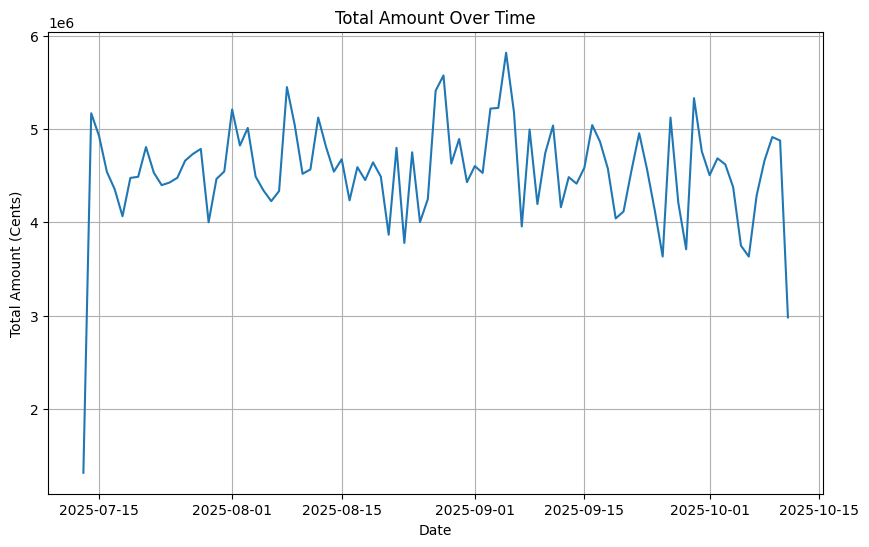

placed_at
2025-09-05    5820443
2025-08-28    5576357
2025-08-08    5451468
2025-08-27    5412831
2025-09-29    5332815
               ...   
2025-09-28    3711887
2025-09-25    3633609
2025-10-06    3632912
2025-10-11    2980753
2025-07-13    1313942
Name: total_amount_cents, Length: 91, dtype: int64


In [ ]:
# Plotting line chart for sum of total amount over time
Data_orders['placed_at'] = pd.to_datetime(Data_orders['placed_at'])

total_amount_over_time = Data_orders.groupby(Data_orders['placed_at'].dt.date)['total_amount_cents'].sum()

total_amount_over_time.plot(kind='line', figsize=(10, 6), title='Total Amount Over Time', xlabel='Date', ylabel='Total Amount (Cents)')
plt.grid()
plt.show()

print(total_amount_over_time.sort_values(ascending=False))

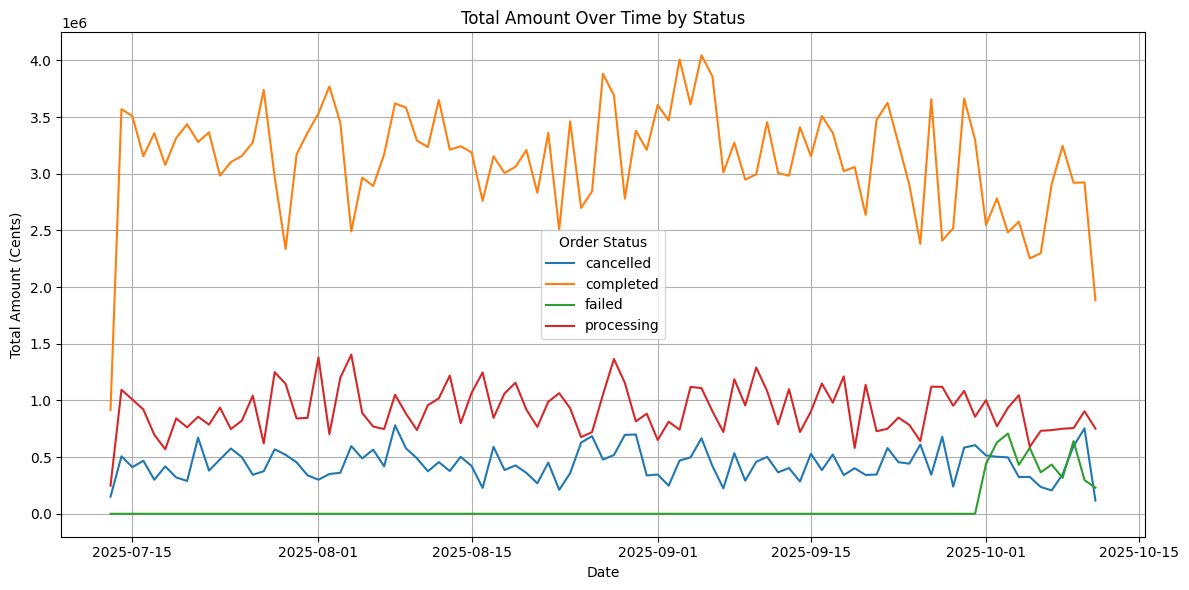

status      cancelled  completed  failed  processing
date                                                
2025-07-13     150975     915141       0      247826
2025-07-14     507042    3570050       0     1093854
2025-07-15     411470    3508616       0     1007993
2025-07-16     468174    3154218       0      920162
2025-07-17     300301    3357788       0      697580
...               ...        ...     ...         ...
2025-10-07     206424    2907759  434204      738356
2025-10-08     348373    3245839  316532      750502
2025-10-09     597308    2920447  641639      756182
2025-10-10     752835    2923530  297097      904706
2025-10-11     115957    1882888  229996      751912

[91 rows x 4 columns]


In [ ]:
# Ensure datetime format
Data_orders['placed_at'] = pd.to_datetime(Data_orders['placed_at'])

# Extract date
Data_orders['date'] = Data_orders['placed_at'].dt.date

# Group by date and status
status_grouped = Data_orders.groupby(['date', 'status'])['total_amount_cents'].sum().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for status in status_grouped.columns:
    plt.plot(status_grouped.index, status_grouped[status], label=status)

plt.title('Total Amount Over Time by Status')
plt.xlabel('Date')
plt.ylabel('Total Amount (Cents)')
plt.legend(title='Order Status')
plt.grid(True)
plt.tight_layout()
plt.show()

print(status_grouped)

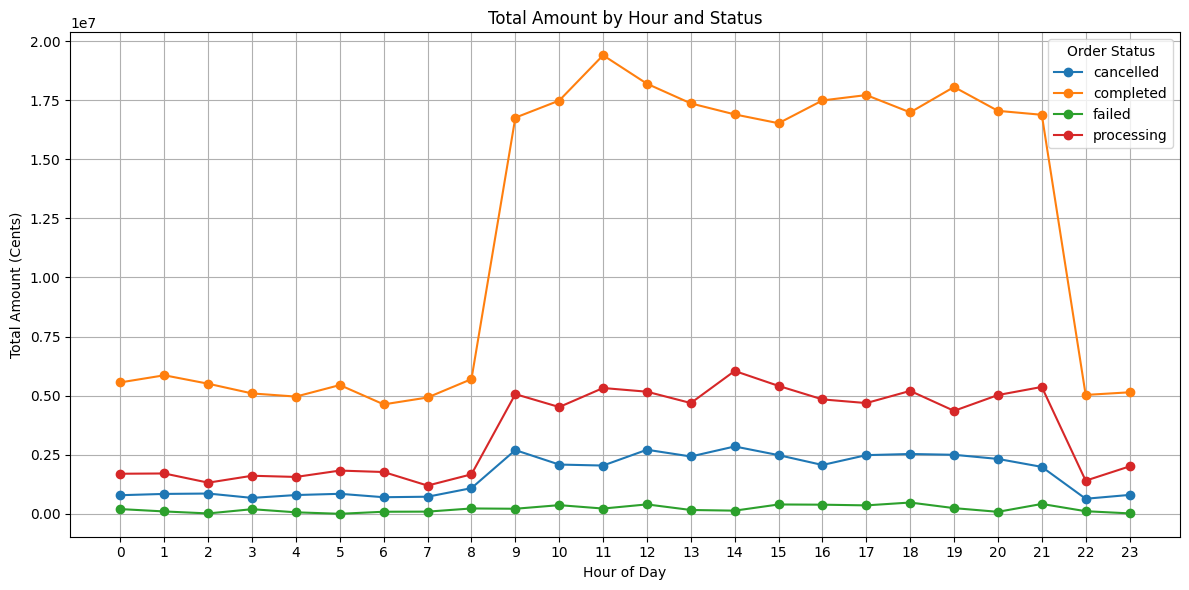

status  cancelled  completed  failed  processing
hour                                            
0          791804    5563168  204208     1699391
1          846208    5863854  104765     1710899
2          861990    5506221   20668     1321897
3          677458    5095631  200112     1614349
4          798447    4962552   67923     1564285
5          850919    5450010    5414     1833383
6          706384    4632851   92266     1772128
7          727638    4923935   97112     1198586
8         1090664    5701174  231217     1674682
9         2699571   16759216  218757     5066837
10        2087669   17481859  371184     4520399
11        2046057   19398182  227664     5325153
12        2713907   18193949  402789     5169199
13        2429340   17362612  166444     4689607
14        2853067   16896970  138230     6046368
15        2486712   16523823  399697     5414505
16        2069467   17487185  390858     4843777
17        2486377   17714207  361641     4688186
18        2534734   

In [ ]:
# Ensure datetime format
Data_orders['placed_at'] = pd.to_datetime(Data_orders['placed_at'])

# Extract hour
Data_orders['hour'] = Data_orders['placed_at'].dt.hour

# Group by hour and status
hourly_status_amount = Data_orders.groupby(['hour', 'status'])['total_amount_cents'].sum().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for status in hourly_status_amount.columns:
    plt.plot(hourly_status_amount.index, hourly_status_amount[status], marker='o', label=status)

plt.title('Total Amount by Hour and Status')
plt.xlabel('Hour of Day')
plt.ylabel('Total Amount (Cents)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()

print(hourly_status_amount)

In [ ]:
Data_orders_fulfilment_merge = pd.merge(Data_orders, Data_fulfillments, on='order_id', how='left')

Data_orders_fulfilment_merge.head()

,order_id,merchant_id,status_x,total_amount_cents,currency,placed_at,source_channel,date,hour,fulfillment_id,carrier,status_y,shipped_at,delivered_at,is_sla_met,delivery_time
0,1,67,completed,18271,SAR,2025-10-08 06:59:30,Web,2025-10-08,6,1.0,DHL,delivered,2025-10-08 21:59:30,2025-10-13 21:59:30,True,5.0
1,2,30,completed,38481,SAR,2025-08-23 10:51:45,Web,2025-08-23,10,2.0,SPL,shipped,2025-08-25 02:51:45,NaT,True,NaN
2,3,38,processing,40396,SAR,2025-07-16 14:49:11,MobileApp,2025-07-16,14,3.0,DHL,shipped,2025-07-17 08:49:11,NaT,True,NaN
3,4,50,completed,31059,SAR,2025-08-25 13:25:16,API,2025-08-25,13,4.0,SPL,delivered,2025-08-26 03:25:16,2025-08-30 03:25:16,True,4.0
4,5,14,completed,24332,SAR,2025-07-20 04:25:25,API,2025-07-20,4,5.0,DHL,shipped,2025-07-20 23:25:25,NaT,True,NaN


In [ ]:
# Ensure datetime format
Data_orders_fulfilment_merge['placed_at'] = pd.to_datetime(Data_orders_fulfilment_merge['placed_at'])
Data_orders_fulfilment_merge['shipped_at'] = pd.to_datetime(Data_orders_fulfilment_merge['shipped_at'])

# Create new column for shipping delay in days
Data_orders_fulfilment_merge['Shipping_delay_days'] = (
    (Data_orders_fulfilment_merge['shipped_at'] - Data_orders_fulfilment_merge['placed_at']).dt.days
)

Data_orders_fulfilment_merge.head()

,order_id,merchant_id,status_x,total_amount_cents,currency,placed_at,source_channel,date,hour,fulfillment_id,carrier,status_y,shipped_at,delivered_at,is_sla_met,delivery_time,Shipping_delay_days
0,1,67,completed,18271,SAR,2025-10-08 06:59:30,Web,2025-10-08,6,1.0,DHL,delivered,2025-10-08 21:59:30,2025-10-13 21:59:30,True,5.0,0.0
1,2,30,completed,38481,SAR,2025-08-23 10:51:45,Web,2025-08-23,10,2.0,SPL,shipped,2025-08-25 02:51:45,NaT,True,NaN,1.0
2,3,38,processing,40396,SAR,2025-07-16 14:49:11,MobileApp,2025-07-16,14,3.0,DHL,shipped,2025-07-17 08:49:11,NaT,True,NaN,0.0
3,4,50,completed,31059,SAR,2025-08-25 13:25:16,API,2025-08-25,13,4.0,SPL,delivered,2025-08-26 03:25:16,2025-08-30 03:25:16,True,4.0,0.0
4,5,14,completed,24332,SAR,2025-07-20 04:25:25,API,2025-07-20,4,5.0,DHL,shipped,2025-07-20 23:25:25,NaT,True,NaN,0.0


In [ ]:
Data_orders_fulfilment_merge['Shipping_delay_days'].value_counts()

Shipping_delay_days
1.0    8616
0.0    4337
2.0     383
Name: count, dtype: int64

In [ ]:
Data_orders_fulfilment_merge.groupby(['status_x','status_y','Shipping_delay_days','delivery_time'])['order_id'].size()

status_x    status_y   Shipping_delay_days  delivery_time
completed   delivered  0.0                  1.0              331
                                            2.0              375
                                            3.0              345
                                            4.0              350
                                            5.0              287
                                            6.0              324
                                            7.0              371
                       1.0                  1.0              717
                                            2.0              650
                                            3.0              671
                                            4.0              704
                                            5.0              666
                                            6.0              705
                                            7.0              684
                       2.0      

In [ ]:
Data_orders_fulfilment_merge.groupby(['status_x', 'status_y'])['Shipping_delay_days'].agg(['mean']).sort_values(by='mean', ascending=False)

mean
status_x   status_y           
processing delivered  0.707066
completed  delivered  0.706129
           shipped    0.702044
           pending    0.695894
processing shipped    0.693023
           pending    0.681604

In [ ]:
# Calculate same-day and next-day shipping percentages
same_day_shipping = Data_orders_fulfilment_merge[Data_orders_fulfilment_merge['Shipping_delay_days'] == 0].shape[0]
next_day_shipping = Data_orders_fulfilment_merge[Data_orders_fulfilment_merge['Shipping_delay_days'] == 1].shape[0]
other_shipping = Data_orders_fulfilment_merge[Data_orders_fulfilment_merge['Shipping_delay_days'] > 1].shape[0]
total_orders = Data_orders_fulfilment_merge.shape[0]

same_day_percent = (same_day_shipping / total_orders) * 100
next_day_percent = (next_day_shipping / total_orders) * 100
other_shipping_percent = (other_shipping / total_orders) * 100


# Calculate Delivery Time SLA percentage for delivery time between 0 to 7 days
sla_met = Data_fulfillments[(Data_fulfillments['delivery_time'] >= 0) & (Data_fulfillments['delivery_time'] <= 7)].shape[0]
total_deliveries = Data_fulfillments.shape[0]
sla_met_percent = (sla_met / total_deliveries) * 100

print(f"Delivery Time SLA percentage (0-7 days): {sla_met_percent:.2f}%")

print(f"Same-day shipping percentage: {same_day_percent:.2f}%")
print(f"Next-day shipping percentage: {next_day_percent:.2f}%")
print(f"Other shipping percentage: {other_shipping_percent:.2f}%")

Delivery Time SLA percentage (0-7 days): 71.45%
Same-day shipping percentage: 28.91%
Next-day shipping percentage: 57.44%
Other shipping percentage: 2.55%


In [ ]:
Data_job_runs = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_job_runs.xlsx")

Data_job_runs.head()

,job_run_id,job_name,started_at,finished_at,status
0,1,InventorySync,2025-08-18 18:37:19,2025-08-18 18:59:44,success
1,2,DailyReporting,2025-08-02 14:56:24,2025-08-02 09:47:37,success
2,3,FraudCheck,2025-09-16 21:17:17,2025-09-16 13:05:08,success
3,4,InventorySync,2025-09-08 11:56:25,2025-09-08 11:03:24,success
4,5,FraudCheck,2025-08-21 15:22:34,2025-08-21 15:29:50,success


In [ ]:
Data_job_runs['started_at'] = pd.to_datetime(Data_job_runs['started_at'])
Data_job_runs['finished_at'] = pd.to_datetime(Data_job_runs['finished_at'])

Data_job_runs['mean_time'] = (Data_job_runs['finished_at'] - Data_job_runs['started_at']).dt.total_seconds()


Data_job_runs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   job_run_id   1500 non-null   int64         
 1   job_name     1500 non-null   object        
 2   started_at   1500 non-null   datetime64[ns]
 3   finished_at  1500 non-null   datetime64[ns]
 4   status       1500 non-null   object        
 5   mean_time    1500 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 70.4+ KB


In [ ]:
Data_job_runs.duplicated().sum()

np.int64(0)

In [ ]:
Data_job_runs.isnull().sum()

job_run_id     0
job_name       0
started_at     0
finished_at    0
status         0
mean_time      0
dtype: int64

In [ ]:
Data_job_runs['job_name'].value_counts()

job_name
DailyReporting    518
FraudCheck        497
InventorySync     485
Name: count, dtype: int64

In [ ]:
Data_job_runs['status'].value_counts()

status
success    1258
failed      242
Name: count, dtype: int64

In [ ]:
Wrong_job_runs_records = Data_job_runs[Data_job_runs['mean_time']<0]

Wrong_job_runs_records

,job_run_id,job_name,started_at,finished_at,status,mean_time
1,2,DailyReporting,2025-08-02 14:56:24,2025-08-02 09:47:37,success,-18527.0
2,3,FraudCheck,2025-09-16 21:17:17,2025-09-16 13:05:08,success,-29529.0
3,4,InventorySync,2025-09-08 11:56:25,2025-09-08 11:03:24,success,-3181.0
6,7,FraudCheck,2025-10-03 09:21:23,2025-10-03 06:50:18,success,-9065.0
7,8,InventorySync,2025-09-17 22:46:20,2025-09-17 14:48:12,success,-28688.0
...,...,...,...,...,...,...
1494,1495,DailyReporting,2025-08-13 21:09:51,2025-08-13 14:45:59,success,-23032.0
1495,1496,DailyReporting,2025-08-06 10:09:52,2025-08-06 08:39:29,success,-5423.0
1497,1498,InventorySync,2025-08-29 21:16:19,2025-08-29 12:32:34,failed,-31425.0
1498,1499,InventorySync,2025-07-15 13:34:31,2025-07-15 03:55:28,success,-34743.0


In [ ]:
correct_job_runs_records = Data_job_runs[Data_job_runs['mean_time']>=0]

correct_job_runs_records.groupby('job_name')['mean_time'].agg(['mean']).sort_values(by='mean', ascending=False)

,mean
job_name,
InventorySync,942.262500
FraudCheck,913.162698
DailyReporting,878.417241


In [ ]:
correct_job_runs_records.groupby(['job_name', 'status'])['mean_time'].agg(['mean']).sort_values(by='mean', ascending=False)

mean
job_name       status              
DailyReporting failed   1061.891892
InventorySync  failed    969.378378
               success   937.320197
FraudCheck     success   913.841121
               failed    909.342105
DailyReporting success   851.584980

In [ ]:
Wrong_job_runs_records_percent = (Wrong_job_runs_records.shape[0] / Data_job_runs.shape[0]) * 100

print(f"Percentage of wrong job runs: {Wrong_job_runs_records_percent:.2f}%")

Percentage of wrong job runs: 47.87%


In [ ]:
Data_payments = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_payments.xlsx")

Data_payments.head()


,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response
0,1,1,67,Payfort,captured,18271,2025-10-08 07:00:34,2025-10-08 06:59:30,False,"{""gateway_status"": ""captured"", ""is_friction"": ..."
1,2,2,30,HyperPay,captured,38481,2025-08-23 10:52:20,2025-08-23 10:51:45,False,"{""gateway_status"": ""captured"", ""is_friction"": ..."
2,3,3,38,Stripe,captured,40396,2025-07-16 13:16:37,2025-07-16 14:49:11,False,"{""gateway_status"": ""captured"", ""is_friction"": ..."
3,4,4,50,HyperPay,captured,31059,2025-08-25 13:30:14,2025-08-25 13:25:16,False,"{""gateway_status"": ""captured"", ""is_friction"": ..."
4,5,5,14,HyperPay,captured,24332,2025-07-20 04:26:12,2025-07-20 04:25:25,False,"{""gateway_status"": ""captured"", ""is_friction"": ..."


In [ ]:
Data_payments['time_to_capture'] = (Data_payments['captured_at'] - Data_payments['created_at']).dt.total_seconds()

In [ ]:
Data_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13520 entries, 0 to 13519
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       13520 non-null  int64         
 1   order_id         13520 non-null  int64         
 2   merchant_id      13520 non-null  int64         
 3   provider         13520 non-null  object        
 4   status           13520 non-null  object        
 5   amount_cents     13520 non-null  int64         
 6   captured_at      13336 non-null  datetime64[ns]
 7   created_at       13520 non-null  datetime64[ns]
 8   is_chargeback    13520 non-null  bool          
 9   raw_response     13520 non-null  object        
 10  time_to_capture  13336 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(1), int64(4), object(3)
memory usage: 1.0+ MB


In [ ]:
Data_payments.duplicated().sum()

np.int64(0)

In [ ]:
Data_payments.isnull().sum()

payment_id           0
order_id             0
merchant_id          0
provider             0
status               0
amount_cents         0
captured_at        184
created_at           0
is_chargeback        0
raw_response         0
time_to_capture    184
dtype: int64

In [ ]:
Data_payments['provider'].value_counts()

provider
HyperPay    4588
Stripe      4522
Payfort     4410
Name: count, dtype: int64

In [ ]:
Data_payments['status'].value_counts()

status
captured    13336
failed        184
Name: count, dtype: int64

In [ ]:
Data_payments['is_chargeback'].value_counts()

is_chargeback
False    13460
True        60
Name: count, dtype: int64

In [ ]:
Data_payments.groupby(['provider', 'status', 'is_chargeback'])['amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

,,,sum
provider,status,is_chargeback,
Stripe,captured,False,124173317
HyperPay,captured,False,122431181
Payfort,captured,False,119919654
HyperPay,failed,False,5076247
Payfort,captured,True,676299
Stripe,captured,True,496960
HyperPay,captured,True,493853


In [ ]:
Data_payments.groupby(['provider', 'status', 'is_chargeback'])['time_to_capture'].agg(['mean']).sort_values(by='mean', ascending=False)

mean
provider status   is_chargeback              
Stripe   captured True           -6005.111111
HyperPay captured True           -9678.333333
                  False         -10789.743809
Stripe   captured False         -11203.321607
Payfort  captured False         -11477.510378
                  True          -15033.000000
HyperPay failed   False                   NaN

In [ ]:
wrong_records = Data_payments[
    (Data_payments['created_at'] > Data_payments['captured_at']) &
    (Data_payments['captured_at'].notnull())
]

wrong_records.head()


,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture
2,3,3,38,Stripe,captured,40396,2025-07-16 13:16:37,2025-07-16 14:49:11,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-5554.0
7,8,9,51,Payfort,captured,7916,2025-07-30 08:24:18,2025-07-30 11:02:38,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-9500.0
9,10,11,82,Stripe,captured,34253,2025-08-27 06:38:20,2025-08-27 11:59:36,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-19276.0
12,13,14,40,HyperPay,captured,29957,2025-07-18 10:21:18,2025-07-18 17:37:18,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-26160.0
14,15,17,94,HyperPay,captured,27364,2025-09-11 13:45:01,2025-09-11 17:09:47,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-12286.0


In [ ]:
wrong_records.shape[0]

6639

In [ ]:
Correct_records = Data_payments[Data_payments['created_at'] < Data_payments['captured_at']]

Correct_records.head()

,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture
0,1,1,67,Payfort,captured,18271,2025-10-08 07:00:34,2025-10-08 06:59:30,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",64.0
1,2,2,30,HyperPay,captured,38481,2025-08-23 10:52:20,2025-08-23 10:51:45,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",35.0
3,4,4,50,HyperPay,captured,31059,2025-08-25 13:30:14,2025-08-25 13:25:16,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",298.0
4,5,5,14,HyperPay,captured,24332,2025-07-20 04:26:12,2025-07-20 04:25:25,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",47.0
5,6,6,13,Stripe,captured,50315,2025-07-22 13:39:35,2025-07-22 13:37:35,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",120.0


In [ ]:
Correct_records.shape[0]

6678

In [ ]:
charged_back_payments = Data_payments[Data_payments['is_chargeback'] == True]

charged_back_payments.head()

,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture
248,249,276,91,HyperPay,captured,19762,2025-08-01 16:23:05,2025-08-01 17:14:39,True,"{""gateway_status"": ""captured"", ""is_friction"": ...",-3094.0
350,351,384,27,Payfort,captured,1718,2025-09-28 15:59:52,2025-09-28 15:57:03,True,"{""gateway_status"": ""captured"", ""is_friction"": ...",169.0
994,995,1095,83,Stripe,captured,22117,2025-09-09 18:34:46,2025-09-09 18:47:54,True,"{""gateway_status"": ""captured"", ""is_friction"": ...",-788.0
1228,1229,1348,74,Stripe,captured,36990,2025-10-10 13:15:41,2025-10-10 21:21:58,True,"{""gateway_status"": ""captured"", ""is_friction"": ...",-29177.0
1248,1249,1368,3,Payfort,captured,18491,2025-07-22 01:58:51,2025-07-22 11:57:32,True,"{""gateway_status"": ""captured"", ""is_friction"": ...",-35921.0


In [ ]:
failed_payments = Data_payments[Data_payments['status'] == 'failed']

failed_payments.head()

,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture
63,64,72,41,HyperPay,failed,31194,NaT,2025-10-03 12:00:54,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
74,75,84,100,HyperPay,failed,4652,NaT,2025-10-08 20:19:35,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
142,143,158,19,HyperPay,failed,8555,NaT,2025-10-08 20:05:09,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
164,165,182,3,HyperPay,failed,48130,NaT,2025-10-02 08:03:31,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
176,177,195,61,HyperPay,failed,9831,NaT,2025-10-10 19:22:34,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN


In [ ]:
failed_not_captured_payments = Data_payments[Data_payments['captured_at'].isnull()]

failed_not_captured_payments.head()

,payment_id,order_id,merchant_id,provider,status,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture
63,64,72,41,HyperPay,failed,31194,NaT,2025-10-03 12:00:54,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
74,75,84,100,HyperPay,failed,4652,NaT,2025-10-08 20:19:35,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
142,143,158,19,HyperPay,failed,8555,NaT,2025-10-08 20:05:09,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
164,165,182,3,HyperPay,failed,48130,NaT,2025-10-02 08:03:31,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN
176,177,195,61,HyperPay,failed,9831,NaT,2025-10-10 19:22:34,False,"{""gateway_status"": ""failed"", ""is_friction"": tr...",NaN


In [ ]:
failed_not_captured_payments.groupby('status')['amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
status,
failed,5076247


In [ ]:
failed_not_captured_payments.groupby('raw_response')['amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
raw_response,
"{""gateway_status"": ""failed"", ""is_friction"": true, ""error_code"": ""PAY-429: Gateway Rate Limit"", ""error_message"": ""External service is throttling requests.""}",5076247


C:\Users\DELL2025\AppData\Local\Temp\ipykernel_3348\725105269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failed_not_captured_payments['created_at'] = pd.to_datetime(failed_not_captured_payments['created_at'])


created_at
2025-10-03    707885
2025-10-09    641639
2025-10-02    629513
2025-10-05    581955
2025-10-01    440426
2025-10-07    434204
2025-10-04    431300
2025-10-06    365700
2025-10-08    316532
2025-10-10    297097
2025-10-11    229996
Name: amount_cents, dtype: int64


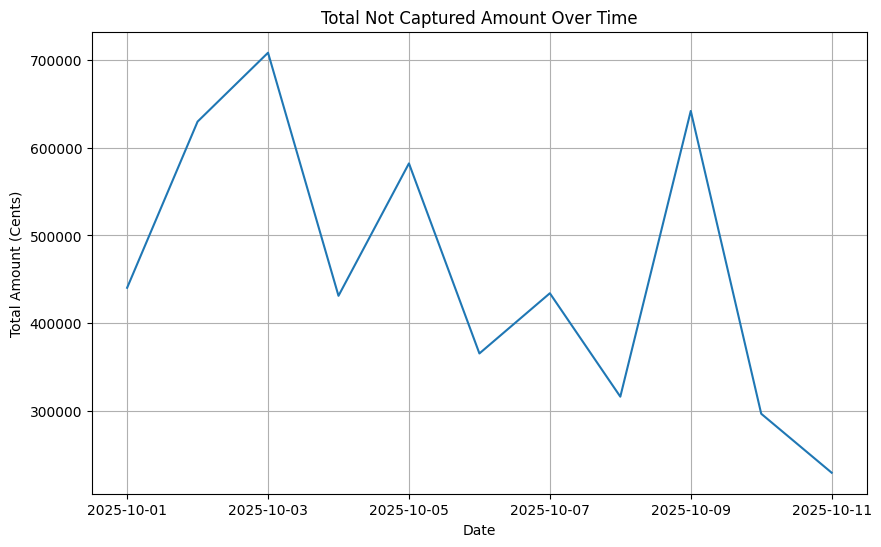

In [ ]:
# Plotting line chart of total not captured amount over time
failed_not_captured_payments['created_at'] = pd.to_datetime(failed_not_captured_payments['created_at'])

total_not_captured_amount_over_time = failed_not_captured_payments.groupby(failed_not_captured_payments['created_at'].dt.date)['amount_cents'].sum()

total_not_captured_amount_over_time.plot(kind='line', figsize=(10, 6), title='Total Not Captured Amount Over Time', xlabel='Date', ylabel='Total Amount (Cents)')
print(total_not_captured_amount_over_time.sort_values(ascending=False))

plt.grid()
plt.show()

created_at
18    481785
21    422009
12    402789
15    399697
16    390858
10    371184
17    361641
19    245360
8     231217
11    227664
9     218757
0     204208
3     200112
13    166444
14    138230
22    114790
1     104765
7      97112
6      92266
20     88613
4      67923
23     22741
2      20668
5       5414
Name: amount_cents, dtype: int64


C:\Users\DELL2025\AppData\Local\Temp\ipykernel_3348\4087395612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failed_not_captured_payments['created_at'] = pd.to_datetime(failed_not_captured_payments['created_at'])


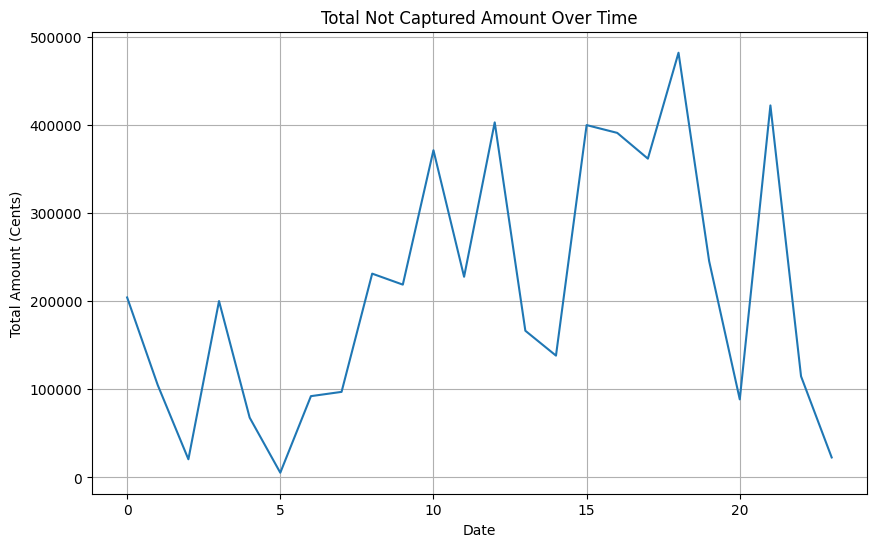

In [ ]:
# Plotting line chart of total not captured amount over hour
failed_not_captured_payments['created_at'] = pd.to_datetime(failed_not_captured_payments['created_at'])

total_not_captured_amount_over_hour = failed_not_captured_payments.groupby(failed_not_captured_payments['created_at'].dt.hour)['amount_cents'].sum()

total_not_captured_amount_over_hour.plot(kind='line', figsize=(10, 6), title='Total Not Captured Amount Over Time', xlabel='Date', ylabel='Total Amount (Cents)')
print(total_not_captured_amount_over_hour.sort_values(ascending=False))
plt.grid()
plt.show()



In [ ]:
payment_order_merge = pd.merge(Data_payments, Data_orders, on='order_id', how='left')

payment_order_merge.head()

,payment_id,order_id,merchant_id_x,provider,status_x,amount_cents,captured_at,created_at,is_chargeback,raw_response,time_to_capture,merchant_id_y,status_y,total_amount_cents,currency,placed_at,source_channel,date,hour
0,1,1,67,Payfort,captured,18271,2025-10-08 07:00:34,2025-10-08 06:59:30,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",64.0,67,completed,18271,SAR,2025-10-08 06:59:30,Web,2025-10-08,6
1,2,2,30,HyperPay,captured,38481,2025-08-23 10:52:20,2025-08-23 10:51:45,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",35.0,30,completed,38481,SAR,2025-08-23 10:51:45,Web,2025-08-23,10
2,3,3,38,Stripe,captured,40396,2025-07-16 13:16:37,2025-07-16 14:49:11,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",-5554.0,38,processing,40396,SAR,2025-07-16 14:49:11,MobileApp,2025-07-16,14
3,4,4,50,HyperPay,captured,31059,2025-08-25 13:30:14,2025-08-25 13:25:16,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",298.0,50,completed,31059,SAR,2025-08-25 13:25:16,API,2025-08-25,13
4,5,5,14,HyperPay,captured,24332,2025-07-20 04:26:12,2025-07-20 04:25:25,False,"{""gateway_status"": ""captured"", ""is_friction"": ...",47.0,14,completed,24332,SAR,2025-07-20 04:25:25,API,2025-07-20,4


In [ ]:
correct_payment_order_merge = payment_order_merge[payment_order_merge['created_at'] < payment_order_merge['captured_at']]

In [ ]:
Payment_Success_Rate = payment_order_merge[payment_order_merge['status_x'] == 'captured'].shape[0] / payment_order_merge.shape[0] *100

Refund_Processing_Time = (correct_payment_order_merge[correct_payment_order_merge['status_x'] == 'captured']['captured_at'] - correct_payment_order_merge['created_at']).mean()
 
Chargeback_rate = payment_order_merge[payment_order_merge['is_chargeback'] == True].shape[0] / payment_order_merge.shape[0] *100


print(f"Payment Success Rate: {Payment_Success_Rate} %")
print(f"Refund Processing Time: {Refund_Processing_Time} hours")
print(f"Chargeback Rate: {Chargeback_rate} %")


Payment Success Rate: 98.63905325443787 %
Refund Processing Time: 0 days 00:02:29.847858640 hours
Chargeback Rate: 0.4437869822485207 %


In [ ]:
payment_order_merge.groupby(['is_chargeback','source_channel'])['amount_cents'].agg(['sum']).sort_values(by='sum', ascending=False)

sum
is_chargeback source_channel           
False         API             127804693
              Web             122051726
              MobileApp       121743980
True          Web                704698
              MobileApp          661849
              API                300565

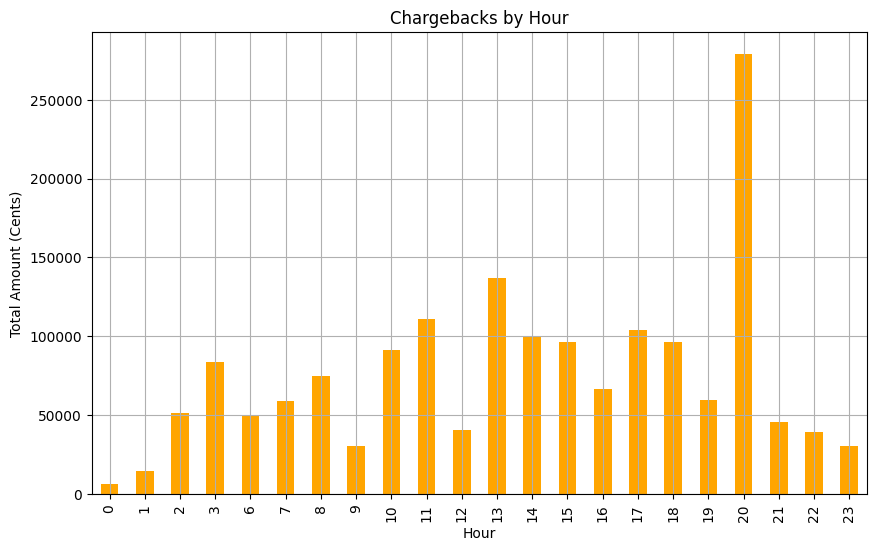

In [ ]:
# Plotting chargebacks against hours
Data_payments['created_at'] = pd.to_datetime(Data_payments['created_at'])
Data_payments['hour'] = Data_payments['created_at'].dt.hour
chargeback_by_hour = Data_payments[Data_payments['is_chargeback'] == True].groupby('hour')['amount_cents'].sum()
plt.figure(figsize=(10, 6))
chargeback_by_hour.plot(kind='bar', title='Chargebacks by Hour', xlabel='Hour', ylabel='Total Amount (Cents)', color='orange')
plt.grid()
plt.show()


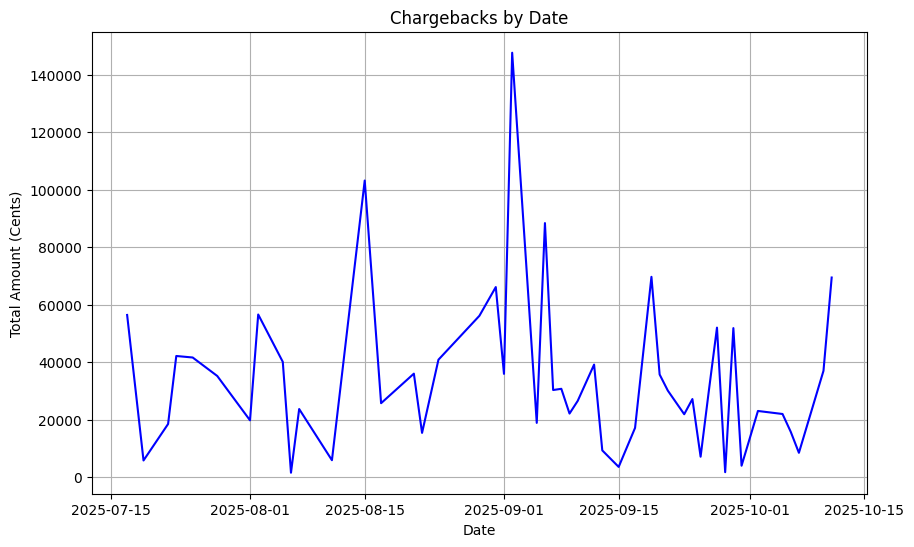

In [ ]:
# Plotting chargebacks against dates
chargeback_by_date = Data_payments[Data_payments['is_chargeback'] == True].groupby(Data_payments['created_at'].dt.date)['amount_cents'].sum()
plt.figure(figsize=(10, 6))
chargeback_by_date.plot(kind='line', title='Chargebacks by Date', xlabel='Date', ylabel='Total Amount (Cents)', color='blue')
plt.grid()
plt.show()

In [ ]:
Data_shipments = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_shipments.xlsx")

Data_shipments.head()


,shipment_id,fulfillment_id,status,delivery_latency_hours
0,1,1,delivered,120.0
1,2,2,shipped,NaN
2,3,3,shipped,NaN
3,4,4,delivered,96.0
4,5,5,shipped,NaN


In [ ]:
Data_shipments.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13336 entries, 0 to 13335
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   shipment_id             13336 non-null  int64  
 1   fulfillment_id          13336 non-null  int64  
 2   status                  13336 non-null  object 
 3   delivery_latency_hours  9528 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 416.9+ KB


In [ ]:
Data_shipments.describe()

,shipment_id,fulfillment_id,delivery_latency_hours
count,13336.00000,13336.00000,9528.000000
mean,6668.50000,6668.50000,95.695214
std,3849.91593,3849.91593,48.352311
min,1.00000,1.00000,24.000000
25%,3334.75000,3334.75000,48.000000
50%,6668.50000,6668.50000,96.000000
75%,10002.25000,10002.25000,144.000000
max,13336.00000,13336.00000,168.000000


In [ ]:
Data_shipments.isnull().sum()

shipment_id                  0
fulfillment_id               0
status                       0
delivery_latency_hours    3808
dtype: int64

In [ ]:
Data_shipments.duplicated().sum()

np.int64(0)

In [ ]:
Data_shipments['status'].value_counts()

status
delivered    9528
shipped      1947
pending      1861
Name: count, dtype: int64

In [ ]:
Data_shipments_null_delivery_latency = Data_shipments[Data_shipments['delivery_latency_hours'].isnull()]

Data_shipments_null_delivery_latency.head()

,shipment_id,fulfillment_id,status,delivery_latency_hours
1,2,2,shipped,NaN
2,3,3,shipped,NaN
4,5,5,shipped,NaN
5,6,6,pending,NaN
9,10,10,pending,NaN


In [ ]:
Data_shipments_null_delivery_latency['status'].value_counts()

status
shipped    1947
pending    1861
Name: count, dtype: int64

In [ ]:
Data_shipments_with_delivery_latency = Data_shipments[Data_shipments['delivery_latency_hours'].notnull()]

Data_shipments_with_delivery_latency.head()

,shipment_id,fulfillment_id,status,delivery_latency_hours
0,1,1,delivered,120.0
3,4,4,delivered,96.0
6,7,7,delivered,144.0
7,8,8,delivered,168.0
8,9,9,delivered,96.0


In [ ]:
Data_shipments_fullfilment_merge = pd.merge(Data_shipments, Data_fulfillments, on='fulfillment_id', how='left')

Data_shipments_fullfilment_merge.head()

,shipment_id,fulfillment_id,status_x,delivery_latency_hours,order_id,carrier,status_y,shipped_at,delivered_at,is_sla_met,delivery_time
0,1,1,delivered,120.0,1,DHL,delivered,2025-10-08 21:59:30,2025-10-13 21:59:30,True,5.0
1,2,2,shipped,NaN,2,SPL,shipped,2025-08-25 02:51:45,NaT,True,NaN
2,3,3,shipped,NaN,3,DHL,shipped,2025-07-17 08:49:11,NaT,True,NaN
3,4,4,delivered,96.0,4,SPL,delivered,2025-08-26 03:25:16,2025-08-30 03:25:16,True,4.0
4,5,5,shipped,NaN,5,DHL,shipped,2025-07-20 23:25:25,NaT,True,NaN


In [ ]:
Data_shipments_fullfilment_merge['delivery_time'] = pd.to_numeric(
    Data_shipments_fullfilment_merge['delivery_time'],
    errors='coerce'
).astype(float)


In [ ]:
numeric_df = Data_shipments_fullfilment_merge.select_dtypes(include=['number'])
data_corr = numeric_df.corr()

data_corr


,shipment_id,fulfillment_id,delivery_latency_hours,order_id,delivery_time
shipment_id,1.000000,1.000000,-0.008261,0.999996,-0.008261
fulfillment_id,1.000000,1.000000,-0.008261,0.999996,-0.008261
delivery_latency_hours,-0.008261,-0.008261,1.000000,-0.008244,1.000000
order_id,0.999996,0.999996,-0.008244,1.000000,-0.008244
delivery_time,-0.008261,-0.008261,1.000000,-0.008244,1.000000


<Axes: >

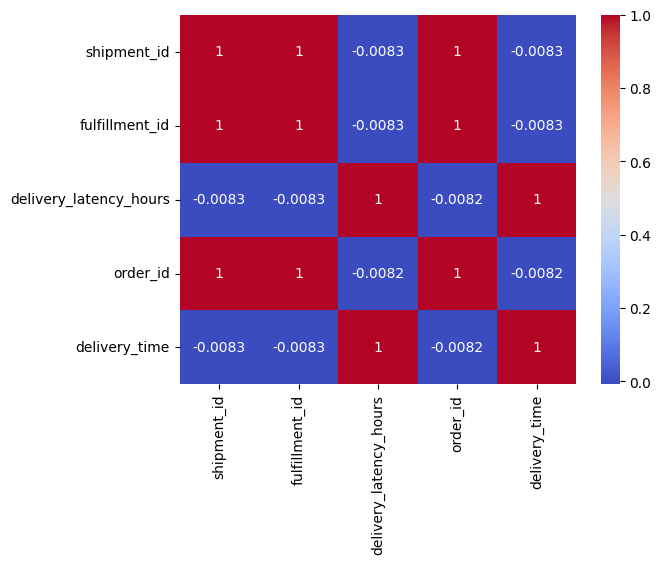

In [ ]:
sns.heatmap(data_corr, annot=True, cmap='coolwarm')


In [ ]:
Data_shipments_fullfilment_merge.groupby(['carrier'])['delivery_latency_hours'].mean().sort_values(ascending=False)

carrier
Aramex    96.796460
DHL       95.297892
SPL       94.997802
Name: delivery_latency_hours, dtype: float64

In [ ]:
Data_shipments_fullfilment_merge.groupby(['carrier'])['delivery_time'].mean().sort_values(ascending=False)

carrier
Aramex    4.033186
DHL       3.970746
SPL       3.958242
Name: delivery_time, dtype: float64

In [ ]:
Data_Sla_report = pd.read_excel(r"E:\python projects\E-Commerce Quality\salla_sla_reports.xlsx")

Data_Sla_report.head()


,sla_report_id,sla_id,period_start,period_end,observed_value,passed,details
0,1,1,2025-08-05 05:12:21,2025-08-05 06:12:21,99.95%,True,NaN
1,2,2,2025-08-25 01:56:33,2025-08-26 01:56:33,99.95%,True,NaN
2,3,2,2025-09-05 19:15:40,2025-09-06 19:15:40,99.95%,True,NaN
3,4,2,2025-07-21 23:32:26,2025-07-22 23:32:26,99.95%,True,NaN
4,5,1,2025-07-24 16:46:19,2025-07-24 17:46:19,99.95%,True,NaN


In [ ]:
Data_Sla_report['duration'] = Data_Sla_report['period_end'] - Data_Sla_report['period_start']
Data_Sla_report['period_end'] = pd.to_datetime(Data_Sla_report['period_end'])
Data_Sla_report['period_start'] = pd.to_datetime(Data_Sla_report['period_start'])
Data_Sla_report['duration'] = Data_Sla_report['duration'].dt.days


In [ ]:
Data_Sla_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sla_report_id   1500 non-null   int64         
 1   sla_id          1500 non-null   int64         
 2   period_start    1500 non-null   datetime64[ns]
 3   period_end      1500 non-null   datetime64[ns]
 4   observed_value  1500 non-null   object        
 5   passed          1500 non-null   bool          
 6   details         0 non-null      float64       
 7   duration        1500 non-null   int64         
dtypes: bool(1), datetime64[ns](2), float64(1), int64(3), object(1)
memory usage: 83.6+ KB


In [ ]:
Data_Sla_report.isnull().sum()

sla_report_id        0
sla_id               0
period_start         0
period_end           0
observed_value       0
passed               0
details           1500
duration             0
dtype: int64

In [ ]:
Data_Sla_report.duplicated().sum()

np.int64(0)

In [ ]:
Data_Sla_report['passed'].value_counts()

passed
True     1407
False      93
Name: count, dtype: int64

In [ ]:
Data_Sla_report['observed_value'].value_counts()

observed_value
99.95%    1407
450ms       47
99.8%       46
Name: count, dtype: int64

In [ ]:
Passed_Sla_reports_rate = Data_Sla_report[Data_Sla_report['passed'] == True].shape[0] / Data_Sla_report.shape[0] *100

print(f"Passed_Sla_reports_rate: {Passed_Sla_reports_rate:.2f}%")

Passed_Sla_reports_rate: 93.80%


In [ ]:
wrong_sla_records_ov = Data_Sla_report[Data_Sla_report['observed_value'] == '450ms']

wrong_sla_records_ov.head()

,sla_report_id,sla_id,period_start,period_end,observed_value,passed,details,duration
27,28,1,2025-10-11 12:53:29,2025-10-12 12:53:29,450ms,False,NaN,1
49,50,1,2025-10-05 11:31:58,2025-10-06 11:31:58,450ms,False,NaN,1
123,124,1,2025-10-06 14:15:49,2025-10-06 15:15:49,450ms,False,NaN,0
178,179,1,2025-10-05 18:17:33,2025-10-06 18:17:33,450ms,False,NaN,1
183,184,1,2025-10-05 08:03:39,2025-10-06 08:03:39,450ms,False,NaN,1


In [ ]:
wrong_sla_records = Data_Sla_report[Data_Sla_report['duration'] < 0]

wrong_sla_records.head()

,sla_report_id,sla_id,period_start,period_end,observed_value,passed,details,duration


In [ ]:

sla_summary = pd.DataFrame({
    "Category": ["API Performance", "API Performance", "API Performance", "API Performance", "API Performance", 
                 "Payment Operations", "Payment Operations", "Payment Operations", "Payment Operations",
                 "Fulfillment & Shipping", "Fulfillment & Shipping", "Fulfillment & Shipping", "Fulfillment & Shipping",
                 "Order Management", "Order Management", "Incident Management", "Incident Management", "Data Quality"],
    
    "Metric": ["Uptime", "Failure Rate", "Average Response Time", "95th Percentile Latency", "99th Percentile Latency",
               "Payment Success Rate", "Chargeback Rate", "Refund Processing Time", "Failed Payment Amount",
               "Same-day Shipping Rate", "Next-day Shipping Rate", "Delivery SLA (0-7 days)", "Avg Delivery Time (days)",
               "Fulfillment Rate", "Order Throughput (orders/day)", "Mean Time to Acknowledge", "Mean Time to Resolve",
               "Data Quality Score"],
    
    "Value": [f"{uptime:.2f}%", f"{failure_rate:.2f}%", f"{avg_response_time:.0f} ms", f"{p95_latency:.0f} ms", f"{p99_latency:.0f} ms",
              f"{Payment_Success_Rate:.2f}%", f"{Chargeback_rate:.2f}%", str(Refund_Processing_Time), f"${(failed_not_captured_payments['amount_cents'].sum()/100):.0f}",
              f"{same_day_percent:.2f}%", f"{next_day_percent:.2f}%", f"{sla_met_percent:.2f}%", f"{Data_fulfillments['delivery_time'].mean():.1f}",
              f"{fulfillment_rate:.2f}%", f"{Throughput:.1f}", str(MTTA), str(MTTR),
              f"{(1 - (wrong_records.shape[0] + wrong_sla_records.shape[0] + Wrong_job_runs_records.shape[0]) / (Data_payments.shape[0] + Data_Sla_report.shape[0] + Data_job_runs.shape[0])) * 100:.1f}%"],
    
    "Status": ["✅" if uptime >= 99 else "⚠️" if uptime >= 95 else "❌",
               "✅" if failure_rate <= 1 else "⚠️" if failure_rate <= 5 else "❌",
               "✅" if avg_response_time <= 200 else "⚠️" if avg_response_time <= 300 else "❌",
               "✅" if p95_latency <= 300 else "⚠️" if p95_latency <= 500 else "❌",
               "✅" if p99_latency <= 500 else "⚠️" if p99_latency <= 1000 else "❌",
               "✅" if Payment_Success_Rate >= 98 else "⚠️" if Payment_Success_Rate >= 95 else "❌",
               "✅" if Chargeback_rate <= 1 else "⚠️" if Chargeback_rate <= 3 else "❌",
               "✅" if Refund_Processing_Time.days <= 2 else "⚠️" if Refund_Processing_Time.days <= 5 else "❌",
               "✅" if (failed_not_captured_payments['amount_cents'].sum()/100) <= 1000 else "⚠️" if (failed_not_captured_payments['amount_cents'].sum()/100) <= 5000 else "❌",
               "✅" if same_day_percent >= 80 else "⚠️" if same_day_percent >= 60 else "❌",
               "✅" if next_day_percent >= 90 else "⚠️" if next_day_percent >= 75 else "❌",
               "✅" if sla_met_percent >= 95 else "⚠️" if sla_met_percent >= 85 else "❌",
               "✅" if Data_fulfillments['delivery_time'].mean() <= 3 else "⚠️" if Data_fulfillments['delivery_time'].mean() <= 5 else "❌",
               "✅" if fulfillment_rate >= 99 else "⚠️" if fulfillment_rate >= 95 else "❌",
               "✅" if Throughput >= 100 else "⚠️" if Throughput >= 50 else "❌",
               "✅" if MTTA.days <= 1 else "⚠️" if MTTA.days <= 2 else "❌",
               "✅" if MTTR.days <= 2 else "⚠️" if MTTR.days <= 5 else "❌",
               "✅" if (1 - (wrong_records.shape[0] + wrong_sla_records.shape[0] + Wrong_job_runs_records.shape[0]) / (Data_payments.shape[0] + Data_Sla_report.shape[0] + Data_job_runs.shape[0])) * 100 >= 99 else "⚠️" if (1 - (wrong_records.shape[0] + wrong_sla_records.shape[0] + Wrong_job_runs_records.shape[0]) / (Data_payments.shape[0] + Data_Sla_report.shape[0] + Data_job_runs.shape[0])) * 100 >= 95 else "❌"],
    
    "Target": ["≥ 99%", "≤ 1%", "≤ 200ms", "≤ 300ms", "≤ 500ms",
               "≥ 98%", "≤ 1%", "≤ 2 days", "≤ $1,000",
               "≥ 80%", "≥ 90%", "≥ 95%", "≤ 3 days",
               "≥ 99%", "≥ 100", "≤ 1 day", "≤ 2 days",
               "≥ 99%"]
})

# Add timestamp and summary statistics
report_date = datetime.now().strftime("%Y-%m-%d")
total_metrics = len(sla_summary)
passed_metrics = len(sla_summary[sla_summary['Status'] == '✅'])
warning_metrics = len(sla_summary[sla_summary['Status'] == '⚠️'])
failed_metrics = len(sla_summary[sla_summary['Status'] == '❌'])

print(f"=== E-commerce Platform SLA Report - {report_date} ===")
print(f"Summary: {passed_metrics}/{total_metrics} Metrics Passed | {warning_metrics} Warnings | {failed_metrics} Failed")
print("=" * 60)

# Display by category for better readability
for category in sla_summary['Category'].unique():
    category_metrics = sla_summary[sla_summary['Category'] == category]
    print(f"\n{category.upper()}:")
    print("-" * 40)
    for _, row in category_metrics.iterrows():
        print(f"  {row['Status']} {row['Metric']}: {row['Value']} (Target: {row['Target']})")

# Critical alerts
critical_alerts = sla_summary[sla_summary['Status'] == '❌']
if not critical_alerts.empty:
    print(f"\n🚨 CRITICAL ALERTS ({len(critical_alerts)}):")
    print("-" * 40)
    for _, alert in critical_alerts.iterrows():
        print(f"  {alert['Metric']}: {alert['Value']} vs Target: {alert['Target']}")

# Display the DataFrame
print(f"\n{'='*80}")
print("Complete SLA Summary DataFrame:")
print(sla_summary[['Category', 'Metric', 'Value', 'Status', 'Target']].to_string(index=False))

=== E-commerce Platform SLA Report - 2025-10-13 ===
Summary: 10/18 Metrics Passed | 3 Warnings | 5 Failed

API PERFORMANCE:
----------------------------------------
  ⚠️ Uptime: 97.24% (Target: ≥ 99%)
  ⚠️ Failure Rate: 2.76% (Target: ≤ 1%)
  ✅ Average Response Time: 196 ms (Target: ≤ 200ms)
  ✅ 95th Percentile Latency: 290 ms (Target: ≤ 300ms)
  ✅ 99th Percentile Latency: 300 ms (Target: ≤ 500ms)

PAYMENT OPERATIONS:
----------------------------------------
  ✅ Payment Success Rate: 98.64% (Target: ≥ 98%)
  ✅ Chargeback Rate: 0.44% (Target: ≤ 1%)
  ✅ Refund Processing Time: 0 days 00:02:29.847858640 (Target: ≤ 2 days)
  ❌ Failed Payment Amount: $50762 (Target: ≤ $1,000)

FULFILLMENT & SHIPPING:
----------------------------------------
  ❌ Same-day Shipping Rate: 28.91% (Target: ≥ 80%)
  ❌ Next-day Shipping Rate: 57.44% (Target: ≥ 90%)
  ❌ Delivery SLA (0-7 days): 71.45% (Target: ≥ 95%)
  ⚠️ Avg Delivery Time (days): 4.0 (Target: ≤ 3 days)

ORDER MANAGEMENT:
---------------------------

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from datetime import datetime
import pandas as pd

# Calculate summary statistics
total_metrics = len(sla_summary)
passed_metrics = len(sla_summary[sla_summary['Status'] == '✅'])
warning_metrics = len(sla_summary[sla_summary['Status'] == '⚠️'])
failed_metrics = len(sla_summary[sla_summary['Status'] == '❌'])

# Create PDF document
today = datetime.now().strftime("%Y-%m-%d")
doc = SimpleDocTemplate(f"SLA_Remediation_Report_{today}.pdf", pagesize=A4)
styles = getSampleStyleSheet()
elements = []

# Custom styles with proper font sizes (FIXED: removed wordWrap parameter)
styles.add(ParagraphStyle(
    name='TableHeader',
    parent=styles['Normal'],
    fontName='Helvetica-Bold',
    fontSize=8,
    textColor=colors.white,
    alignment=1  # Center
))

styles.add(ParagraphStyle(
    name='TableCell',
    parent=styles['Normal'],
    fontName='Helvetica',
    fontSize=7,
    alignment=1  # Center
))

styles.add(ParagraphStyle(
    name='TableCellLeft',
    parent=styles['Normal'],
    fontName='Helvetica',
    fontSize=7,
    alignment=0  # Left
))

styles.add(ParagraphStyle(
    name='CategoryHeader',
    parent=styles['Normal'],
    fontName='Helvetica-Bold',
    fontSize=8,
    textColor=colors.black,
    alignment=0,  # Left
    backColor=colors.lightgrey
))

# ============================================================================
# EXECUTIVE SUMMARY & CURRENT STATUS
# ============================================================================

title = Paragraph(f"SLA Remediation Framework Report", styles['Title'])
elements.append(title)
elements.append(Spacer(1, 0.1*inch))

# Executive Summary with remediation focus
summary_text = f"""
<para alignment="center">
    <b>Executive Summary:</b> {passed_metrics}/{total_metrics} Metrics Passed | 
    <font color="orange">{warning_metrics} Require Monitoring</font> | 
    <font color="red">{failed_metrics} Require Immediate Remediation</font>
    <br/>
    <b>Remediation Priority:</b> {failed_metrics} Critical | {warning_metrics} Major | {passed_metrics} Stable
</para>
"""
summary = Paragraph(summary_text, styles['Normal'])
elements.append(summary)
elements.append(Spacer(1, 0.2*inch))

# ============================================================================
# 🟥 CRITICAL SLA DEVIATIONS (Below 97%)
# ============================================================================

critical_alerts = sla_summary[sla_summary['Status'] == '❌']
if not critical_alerts.empty:
    critical_title = Paragraph("<b>🟥 CRITICAL SLA DEVIATIONS - IMMEDIATE ACTION REQUIRED</b>", styles['Heading2'])
    elements.append(critical_title)
    
    # Critical alerts table with proper column widths
    critical_data = [['Metric', 'Current Value', 'Target', 'Status', 'Severity']]
    for _, alert in critical_alerts.iterrows():
        # Truncate long metric names for better display
        metric_name = alert['Metric']
        if len(metric_name) > 30:
            metric_name = metric_name[:27] + "..."
            
        critical_data.append([
            metric_name,
            alert['Value'],
            alert['Target'],
            "❌ CRITICAL",
            "🟥 HIGH"
        ])
    
    critical_table = Table(critical_data, 
                          colWidths=[2.0*inch, 1.0*inch, 0.8*inch, 0.8*inch, 0.8*inch])
    critical_table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.red),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("BACKGROUND", (0, 1), (-1, -1), colors.mistyrose),
        ("TEXTCOLOR", (0, 1), (-1, -1), colors.darkred),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, 0), 8),
        ("FONTSIZE", (0, 1), (-1, -1), 7),
    ]))
    elements.append(critical_table)
    elements.append(Spacer(1, 0.2*inch))

    # Critical Remediation Actions
    critical_remediation = Paragraph("""
    <b>🟥 CRITICAL REMEDIATION ACTIONS:</b>
    <br/>
    • Activate Incident Command System immediately
    • Redirect traffic to backup data center
    • Implement automatic service credits
    • Activate backup payment processors
    • Deploy emergency hotfixes
    """, styles['Normal'])
    elements.append(critical_remediation)
    elements.append(Spacer(1, 0.3*inch))

# ============================================================================
# 🟧 MAJOR SLA DEVIATIONS (97% - 99%)
# ============================================================================

warning_alerts = sla_summary[sla_summary['Status'] == '⚠️']
if not warning_alerts.empty:
    warning_title = Paragraph("<b>🟧 MAJOR SLA DEVIATIONS - PROACTIVE MONITORING REQUIRED</b>", styles['Heading2'])
    elements.append(warning_title)
    
    warning_data = [['Metric', 'Current Value', 'Target', 'Status', 'Severity']]
    for _, warning in warning_alerts.iterrows():
        # Truncate long metric names for better display
        metric_name = warning['Metric']
        if len(metric_name) > 30:
            metric_name = metric_name[:27] + "..."
            
        warning_data.append([
            metric_name,
            warning['Value'],
            warning['Target'],
            "⚠️ WARNING",
            "🟧 MEDIUM"
        ])
    
    warning_table = Table(warning_data, 
                         colWidths=[2.0*inch, 1.0*inch, 0.8*inch, 0.8*inch, 0.8*inch])
    warning_table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.orange),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("BACKGROUND", (0, 1), (-1, -1), colors.lightyellow),
        ("TEXTCOLOR", (0, 1), (-1, -1), colors.darkorange),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, 0), 8),
        ("FONTSIZE", (0, 1), (-1, -1), 7),
    ]))
    elements.append(warning_table)
    elements.append(Spacer(1, 0.2*inch))

    # Major Remediation Actions
    major_remediation = Paragraph("""
    <b>🟧 MAJOR REMEDIATION ACTIONS:</b>
    <br/>
    • Scale up infrastructure resources
    • Implement caching layers (Redis, CDN)
    • Deploy query optimization
    • Run data validation scripts
    • Implement data reconciliation
    """, styles['Normal'])
    elements.append(major_remediation)
    elements.append(Spacer(1, 0.3*inch))

# ============================================================================
# COMPLETE SLA PERFORMANCE SUMMARY
# ============================================================================

elements.append(PageBreak())
table_title = Paragraph("<b>Complete SLA Performance Summary</b>", styles['Heading1'])
elements.append(table_title)
elements.append(Spacer(1, 0.1*inch))

# Prepare simplified table data to avoid formatting issues
table_data = [['Category', 'Metric', 'Value', 'Status', 'Target', 'Priority']]

current_category = ""
for _, row in sla_summary.iterrows():
    if row['Category'] != current_category:
        current_category = row['Category']
        # Add category header row
        table_data.append([f"▸ {current_category.upper()}", "", "", "", "", ""])
    
    # Determine remediation priority
    if row['Status'] == '❌':
        priority = "🟥 CRITICAL"
    elif row['Status'] == '⚠️':
        priority = "🟧 MAJOR" 
    else:
        priority = "🟩 STABLE"
    
    # Truncate long metric names
    metric_name = row['Metric']
    if len(metric_name) > 25:
        metric_name = metric_name[:22] + "..."
    
    table_data.append([
        "",  # Empty for sub-rows under category
        metric_name,
        row['Value'],
        row['Status'],
        row['Target'],
        priority
    ])

# Create main table with optimized column widths
table = Table(table_data, 
              colWidths=[1.0*inch, 2.0*inch, 0.8*inch, 0.6*inch, 0.8*inch, 0.8*inch])

# Apply table styles
table_style = TableStyle([
    # Header row
    ("BACKGROUND", (0, 0), (-1, 0), colors.darkblue),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, 0), 8),
    ("ALIGN", (0, 0), (-1, 0), "CENTER"),
    
    # Global cell settings
    ("ALIGN", (0, 1), (-1, -1), "CENTER"),
    ("VALIGN", (0, 1), (-1, -1), "MIDDLE"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("FONTSIZE", (0, 1), (-1, -1), 7),
    
    # Category header rows - make them span all columns
    ("SPAN", (0, 1), (-1, 1)),
    ("BACKGROUND", (0, 1), (-1, 1), colors.lightgrey),
    ("FONTNAME", (0, 1), (-1, 1), "Helvetica-Bold"),
    ("ALIGN", (0, 1), (-1, 1), "LEFT"),
])

# Apply category spans for other category rows
category_indices = [i for i, row in enumerate(table_data) if row[0].startswith("▸")]
for idx in category_indices:
    table_style.add('SPAN', (0, idx), (-1, idx))
    table_style.add('BACKGROUND', (0, idx), (-1, idx), colors.lightgrey)
    table_style.add('FONTNAME', (0, idx), (-1, idx), "Helvetica-Bold")
    table_style.add('ALIGN', (0, idx), (-1, idx), "LEFT")

# Apply row-specific background colors
for i in range(2, len(table_data)):
    if i not in category_indices:  # Skip category rows
        status_cell = table_data[i][3] if len(table_data[i]) > 3 else ''
        if status_cell == '❌':
            table_style.add('BACKGROUND', (0, i), (-1, i), colors.mistyrose)
            table_style.add('TEXTCOLOR', (0, i), (-1, i), colors.darkred)
        elif status_cell == '⚠️':
            table_style.add('BACKGROUND', (0, i), (-1, i), colors.lightyellow)
            table_style.add('TEXTCOLOR', (0, i), (-1, i), colors.darkorange)
        elif status_cell == '✅':
            table_style.add('BACKGROUND', (0, i), (-1, i), colors.honeydew)
            table_style.add('TEXTCOLOR', (0, i), (-1, i), colors.darkgreen)

table.setStyle(table_style)
elements.append(table)
elements.append(Spacer(1, 0.2*inch))

# ============================================================================
# STRATEGIC RECOMMENDATIONS & TIMELINE
# ============================================================================

elements.append(PageBreak())
strategic_title = Paragraph("<b>🎯 STRATEGIC RECOMMENDATIONS</b>", styles['Heading1'])
elements.append(strategic_title)
elements.append(Spacer(1, 0.1*inch))

# Simplified Timeline Table
timeline_data = [
    ['Timeline', 'Key Initiative', 'Expected Impact'],
    ['🟢 0-3 Months', 'Enhanced Monitoring & Auto-Remediation', 'Reduce MTTR by 50%'],
    ['🟡 3-6 Months', 'Multi-region Deployment & Analytics', 'Achieve 99.95% SLA'],
    ['🔴 6-12 Months', 'Zero-touch Operations', 'Prevent 90% breaches']
]

timeline_table = Table(timeline_data, 
                      colWidths=[1.2*inch, 2.5*inch, 2.3*inch])
timeline_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.darkgreen),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (0, 1), colors.honeydew),
    ("BACKGROUND", (0, 2), (0, 2), colors.lightyellow),
    ("BACKGROUND", (0, 3), (0, 3), colors.mistyrose),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 8),
]))
elements.append(timeline_table)
elements.append(Spacer(1, 0.3*inch))

# Success Measurement
success_title = Paragraph("<b>📈 SUCCESS MEASUREMENT</b>", styles['Heading2'])
elements.append(success_title)

success_data = [
    ['Metric', 'Current', 'Target', 'Impact'],
    ['SLA Compliance', f'{uptime:.2f}%', '99.95%', 'Reduced credits'],
    ['MTTR (Critical)', 'TBD', '< 30 min', 'Better satisfaction'],
    ['Incident Recurrence', 'TBD', '< 5%', 'Higher efficiency'],
    ['Merchant CSAT', 'TBD', '> 95%', 'Improved retention']
]

success_table = Table(success_data, 
                     colWidths=[1.5*inch, 0.8*inch, 1.0*inch, 1.7*inch])
success_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.navy),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("BACKGROUND", (0, 1), (-1, -1), colors.whitesmoke),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 8),
]))
elements.append(success_table)

# ============================================================================
# LEGEND & CLOSING
# ============================================================================

elements.append(Spacer(1, 0.3*inch))
legend_text = """
<b>REMEDIATION PRIORITY LEGEND:</b>
<br/>
<font color="red">🟥 CRITICAL</font> - Below 97%, immediate action required
<br/>
<font color="orange">🟧 MAJOR</font> - 97%-99%, proactive monitoring needed  
<br/>
<font color="green">🟩 STABLE</font> - Above 99%, meeting targets
<br/><br/>
<b>Report Generated:</b> {date}
<br/>
<b>Next Review:</b> {next_review}
""".format(
    date=datetime.now().strftime("%Y-%m-%d %H:%M"),
    next_review=(datetime.now() + pd.Timedelta(days=7)).strftime("%Y-%m-%d")
)

legend = Paragraph(legend_text, styles['Normal'])
elements.append(legend)

# Build the PDF
doc.build(elements)

print(f"✅ Comprehensive SLA Remediation Report created: SLA_Remediation_Report_{today}.pdf")
print(f"📊 Executive Summary: {passed_metrics}/{total_metrics} Stable | {warning_metrics} Major | {failed_metrics} Critical")
print(f"🚨 Critical items requiring immediate action: {len(critical_alerts)}")
print(f"⚠️  Major items requiring monitoring: {len(warning_alerts)}")

if not critical_alerts.empty:
    print("\n🟥 CRITICAL REMEDIATION PRIORITIES:")
    for _, alert in critical_alerts.iterrows():
        print(f"   • {alert['Metric']}: {alert['Value']} (Target: {alert['Target']})")

if not warning_alerts.empty:
    print("\n🟧 MAJOR MONITORING ITEMS:")
    for _, warning in warning_alerts.iterrows():
        print(f"   • {warning['Metric']}: {warning['Value']} (Target: {warning['Target']})")

print(f"SLA Report created: SLA_Report_{today}.pdf")

✅ Comprehensive SLA Remediation Report created: SLA_Remediation_Report_2025-10-13.pdf
📊 Executive Summary: 10/18 Stable | 3 Major | 5 Critical
🚨 Critical items requiring immediate action: 5
⚠️  Major items requiring monitoring: 3

🟥 CRITICAL REMEDIATION PRIORITIES:
   • Failed Payment Amount: $50762 (Target: ≤ $1,000)
   • Same-day Shipping Rate: 28.91% (Target: ≥ 80%)
   • Next-day Shipping Rate: 57.44% (Target: ≥ 90%)
   • Delivery SLA (0-7 days): 71.45% (Target: ≥ 95%)
   • Data Quality Score: 55.5% (Target: ≥ 99%)

🟧 MAJOR MONITORING ITEMS:
   • Uptime: 97.24% (Target: ≥ 99%)
   • Failure Rate: 2.76% (Target: ≤ 1%)
   • Avg Delivery Time (days): 4.0 (Target: ≤ 3 days)
SLA Report created: SLA_Report_2025-10-13.pdf
